# ACCESS Metrics report for Purdue

In [2]:
PROVIDER = 'Purdue'
RESOURCE_RENAMES = {
    'Purdue Anvil CPU': 'Anvil CPU',
    'Purdue Anvil GPU': 'Anvil GPU',
}

In [3]:
YEAR = 2025
QUARTER_START_DATE_SUFFIX = '-01-01'
QUARTER_START_DATE = str(YEAR) + QUARTER_START_DATE_SUFFIX
QUARTER_END_DATE_SUFFIX = '-03-31'
QUARTER_END_DATE = str(YEAR) + QUARTER_END_DATE_SUFFIX
TWO_YEARS_AGO_QUARTER_START_DATE = str(YEAR - 2) + QUARTER_START_DATE_SUFFIX

In [7]:
# This cell will be removed once JWT implementation is complete.
import os
from pathlib import Path
from dotenv import load_dotenv

load_dotenv(Path(os.path.expanduser('~/xdmod-data.env')), override=True)
os.environ['XDMOD_API_TOKEN'] = os.environ['PROD_API_TOKEN']

In [82]:
import sys
! {sys.executable} -m pip install --upgrade 'xdmod-data>=1.0.0,<2.0.0' python-dotenv tabulate
! {sys.executable} -m pip install  --upgrade xdmod-data
! {sys.executable} -m pip install pandas
! {sys.executable} -m pip install requests
! {sys.executable} -m pip install itables

The system cannot find the file specified.


In [6]:
import pandas as pd
import plotly.express as px
import plotly.io as pio
import xdmod_data.themes
import itables
pio.templates.default = 'timeseries'
from xdmod_data.warehouse import DataWarehouse
from datetime import datetime, timedelta
from IPython.display import display, Markdown, HTML, Javascript
try:
    pd.set_option('future.no_silent_downcasting',True)
except pd.errors.OptionError:
    pass
def display_df_md_table(df):
    return display(Markdown(df.replace('\n', '<br/>', regex=True).to_markdown(floatfmt=',.0f')))
dw = DataWarehouse('https://xdmod.access-ci.org')

In [7]:
def create_plot(metric_label, resource, dimension_label, df,vertical_legend,nlargest):
        
        top_dimension_labels = None
        category_orders = None
        current_quarter_top_projects = []
        title = metric_label + (
            (f' on {resource}')
            if resource != 'all'
            else ''
        ) + f' by {dimension_label} by Quarter, Last Two Years'

        if nlargest > 0:
            
            list1 = df['Date'].unique().tolist()
            top_dimension_labels = []
            CURRENT_QUARTER = QUARTER_START_DATE + " 00:00:00"
                
            for date in list1:
                
                list2 = df[
                    df['Date'] == date
                ].nlargest(
                    nlargest,
                    metric_label,
                )[dimension_label].tolist()
                str_date = date.strftime('%Y-%m-%d %H:%M:%S')
    
                if str_date == CURRENT_QUARTER:
                    current_quarter_top_projects += list2
                    
                top_dimension_labels += list2
            top_dimension_labels = list(set(top_dimension_labels))
            df = df[df[dimension_label].isin(top_dimension_labels)]
            category_orders = {
                    dimension_label: top_dimension_labels,
                }
            title += f', Top {nlargest}'
            
            
            
        plot = px.line(
            df,
            x='Date',
            y=metric_label,
            title=title,
            color=dimension_label,
            markers=True,
            category_orders=category_orders,
        )
        plot.update_traces(
            hovertemplate='%{y:,.0f}',
        )
        plot.update_layout(
            xaxis_tickformat='Q%q %Y',
            hovermode='x unified',
            hoverlabel_namelength=-1,
        )
        if vertical_legend:
            plot.update_layout(
                legend_orientation='v',
                legend_xanchor='left',
                legend_x=0,
                legend_yanchor='bottom',
                legend_y=-1.3
            )
        plot.show()
        
        return (top_dimension_labels, current_quarter_top_projects)


def two_year_line_plot_by_quarter(
    y=None,
    resource=None,
    dimension=None,
    nlargest=0,
    vertical_legend=False
):
    if y == 'projects':
        metric = 'Number of Allocations: Active'
        metric_label = 'Number of Active Projects'
    elif y == 'users':
        metric = 'Number of Users: Active'
        metric_label = 'Number of Active Users'
    elif y == 'ace':
        metric = 'ACCESS Credit Equivalents Charged: Total (SU)'
        metric_label = 'ACCESS Credit Equivalents Charged'
    elif y == 'institutions':
        metric = 'Number of Institutions: Active'
        metric_label = 'Number of Institutions: Active'

    if resource == 'all':
        dimension = dimension_label = 'Resource'
        filters = {
            'Service Provider': PROVIDER,
        }
    else:
        filters = {
            'Resource': resource,
        }
    realm = 'Jobs'
    if dimension == 'pfos':
        dimension = 'Parent Science'
        dimension_label = 'Parent Field of Science'
    elif dimension == 'academic status':
        dimension = 'User NSF Status'
        dimension_label = 'User Academic Status'
    elif dimension == 'project':
        dimension = 'Allocation'
        dimension_label = 'Project'
    elif dimension == 'project type':
        realm = 'Allocations'
        dimension = 'Board Type'
        dimension_label = 'Project Type'
    with dw:
        df = dw.get_data(
            duration=(TWO_YEARS_AGO_QUARTER_START_DATE, QUARTER_END_DATE),
            realm=realm,
            metric=metric,
            dimension=dimension,
            dataset_type='timeseries',
            aggregation_unit='Quarter',
            filters=filters,
        )
    df = df.rename(
        columns={
            **RESOURCE_RENAMES,
            **{dimension: dimension_label}
        }
    )
    df = df.reset_index(names='Date')
    df = pd.melt(
        df,
        id_vars=['Date'],
        var_name=dimension_label,
        value_name=metric_label,
    
    )
    
    return create_plot(metric_label, resource, dimension_label, df,vertical_legend,nlargest)

## Active Projects

### Total

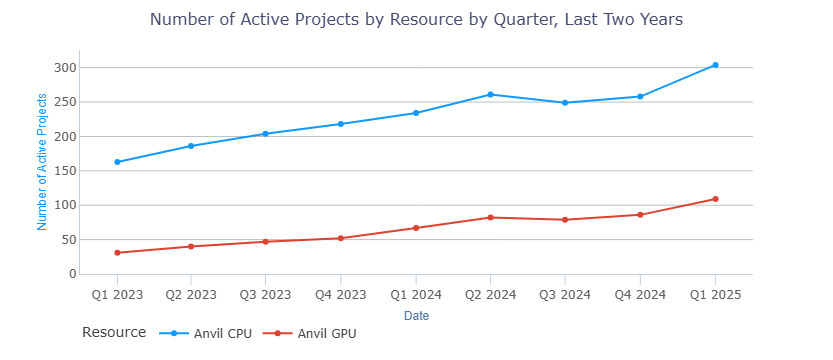

(None, [])

In [113]:
two_year_line_plot_by_quarter(
    y='projects',
    resource='all',
)

### By Project Type

In [12]:
def plot_num_projects_by_type(resource):
    with dw:
        df=dw.get_data(
            realm='Jobs',
            dimension = 'Allocation',
            filters = {
                'Resource': resource,
                },
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            aggregation_unit='Quarter',
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)'
        )

    list1 =df.columns.tolist()
    date_string_index = df.index.strftime('%Y-%m-%d')

    i=0
    while(i < 9):
        with dw:
           df2 =dw.get_raw_data(
               duration=(date_string_index[i],date_string_index[i+1]),
               realm='Allocations',
               fields = {'Name','Board Type'},
               filters = {'Resource': resource,}
            )
        filtered_df = df2[df2['Name'].isin(list1)].reset_index()
        filtered2_df = filtered_df.groupby(['Board Type']).count()
        filtered2_df = filtered2_df.reset_index()
        filtered2_df = filtered2_df.rename(columns={"Board Type": "Project Type", "Name": "Number of Active Projects"})
        filtered2_df = filtered2_df.drop(columns=['index'])
        filtered2_df.insert(0,"Date",date_string_index[i])
        if(i >= 1):
            filtered2_df = pd.concat([previous_df,filtered2_df])
        
        previous_df = filtered2_df
        i+=1
    create_plot(metric_label = 'Number of Active Projects', resource=resource, 
        dimension_label='Project Type', df=filtered2_df,vertical_legend = False,nlargest=0)


plot_num_projects_by_type('Purdue Anvil GPU')
plot_num_projects_by_type('Purdue Anvil CPU')

IndexError: index 1 is out of bounds for axis 0 with size 1

### Some Projects started as one type but later changed to a different type

### By Parent Field of Science

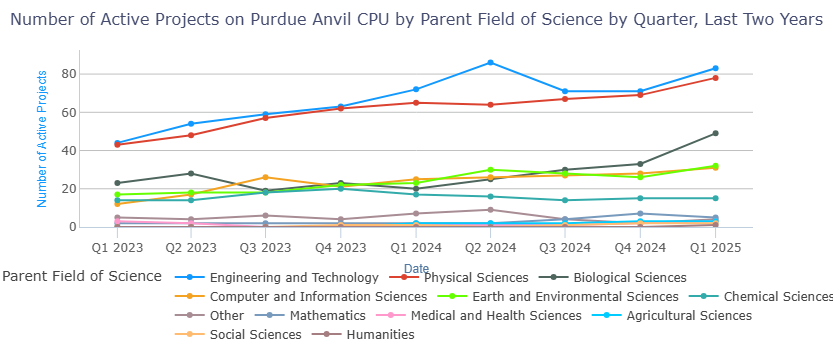

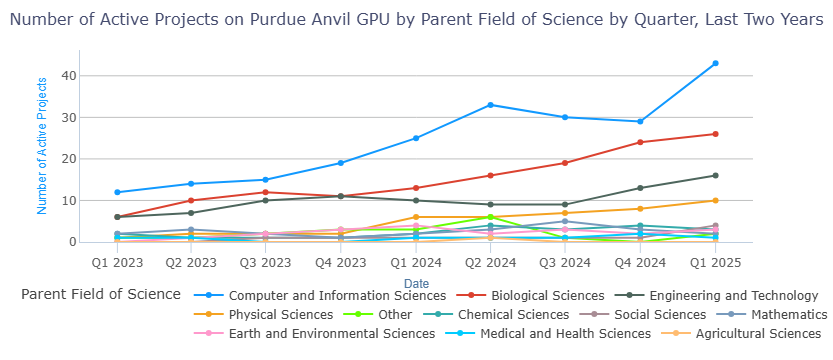

(None, [])

In [27]:
two_year_line_plot_by_quarter(
    y='projects',
    resource='Purdue Anvil CPU',
    dimension='pfos',
)

two_year_line_plot_by_quarter(
    y='projects',
    resource='Purdue Anvil GPU',
    dimension='pfos',
)

### TITLEEE

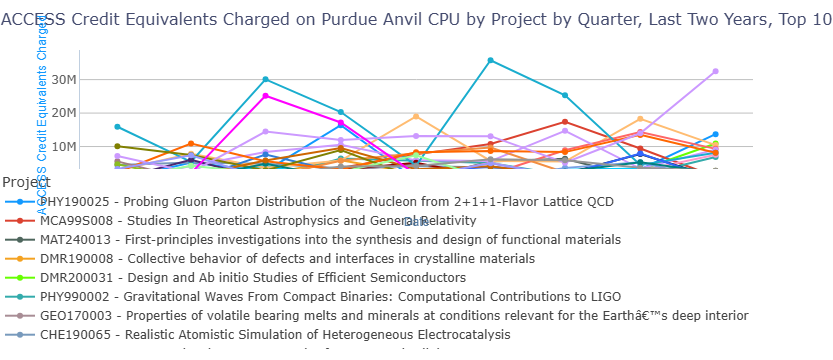

In [29]:
top_projects , current_quarter_top_projects = two_year_line_plot_by_quarter(
    y='ace',
    resource='Purdue Anvil CPU',
    dimension='project',
    nlargest=10,
    vertical_legend=True,
)


In [31]:
resources = ['Purdue Anvil CPU', 'Purdue Anvil GPU']

with dw:
    for resource in resources:
        
        df_ace_charged = dw.get_data(
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            realm = 'Jobs',
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)',
            dimension = 'Allocation',
            dataset_type = 'aggregate',
            filters = {'Resource': resource},
        )
        
        df_jobs_ran = dw.get_data(
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            realm = 'Jobs',
            metric = 'Number of Jobs Running',
            dimension ='Allocation',
            dataset_type ='aggregate',
            filters = {'Resource': resource},
        )
        
        df_all_projects = dw.get_raw_data(
                   duration = (QUARTER_START_DATE,QUARTER_END_DATE),
                   realm = 'Allocations',
                   filters = {'Resource': resource}
        )
        
        active_projects = df_ace_charged.index.tolist()
        
        
        df_active_projects = df_all_projects[df_all_projects['Name'].isin(active_projects)]
        df_active_projects = df_active_projects[['Name', 'Initial Start Date', 'Board Type','Field of Science','Parent Science']]
        df_active_projects = df_active_projects.rename(columns={
            'Board Type': 'Type',
            'Name': 'Title'
        })
        df_active_projects = df_active_projects.sort_values(by='Initial Start Date')
        df_active_projects = df_active_projects.groupby(
            ['Title','Field of Science','Parent Science']
        ).agg(
            {'Type': lambda x: ' -> '.join(list(dict.fromkeys(x)))}
        )
        df_active_projects = df_active_projects.reset_index().set_index('Title')
        
        df_active_projects = df_active_projects.join(df_ace_charged)
        df_active_projects = df_active_projects.join(df_jobs_ran)
        
        
        df_active_projects = df_active_projects.rename(columns={
            'Number of Jobs Running':'Number of Jobs',
            'ACCESS Credit Equivalents Charged: Total (SU)':'ACCESS Credit Equivalents Charged'
        })
        
        df_active_projects = df_active_projects.reset_index()
        
        
        df_active_projects[['Charge Number', 'Title']] = df_active_projects['Title'].str.split('-', n=1, expand=True)
        df_active_projects = df_active_projects.set_index('Charge Number')
        
        with pd.option_context("display.float_format", "{:,.2f}".format):
            itables.show(df_active_projects,column_filters= "header",columnDefs=[{"width": "500px","className": "dt-left", "targets": "_all",}],autoWidth=False)

Loading ITables v2.4.0 from the internet... (need help?)


Loading ITables v2.4.0 from the internet... (need help?)


### ALL PROJECTS

## Active Users

### Total

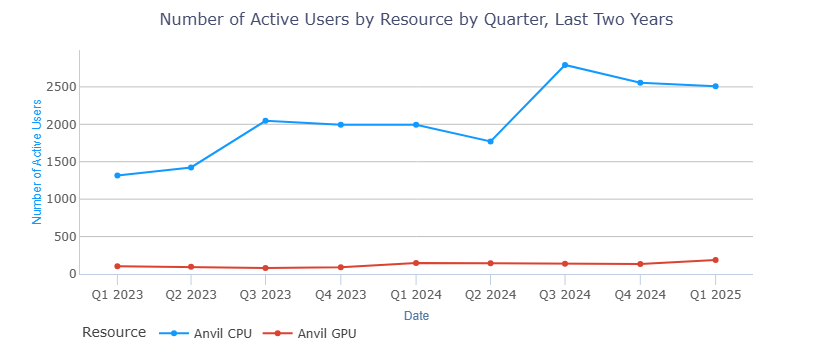

(None, [])

In [33]:
two_year_line_plot_by_quarter(
    y='users',
    resource='all',
)

### By Parent Field of Science

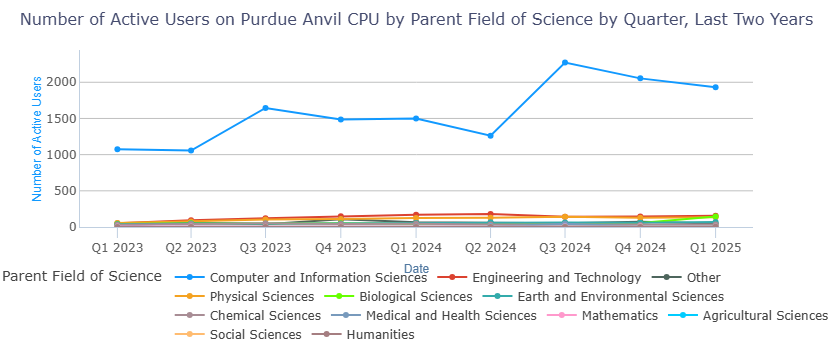

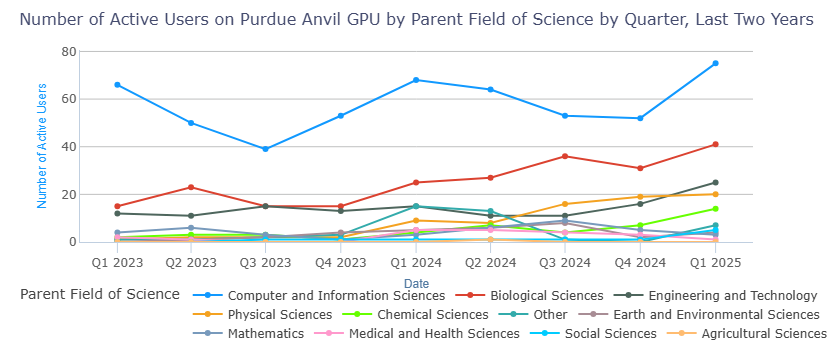

(None, [])

In [35]:
two_year_line_plot_by_quarter(
    y='users',
    resource='Purdue Anvil CPU',
    dimension='pfos',
)

two_year_line_plot_by_quarter(
    y='users',
    resource='Purdue Anvil GPU',
    dimension='pfos',
)

### By Academic Status

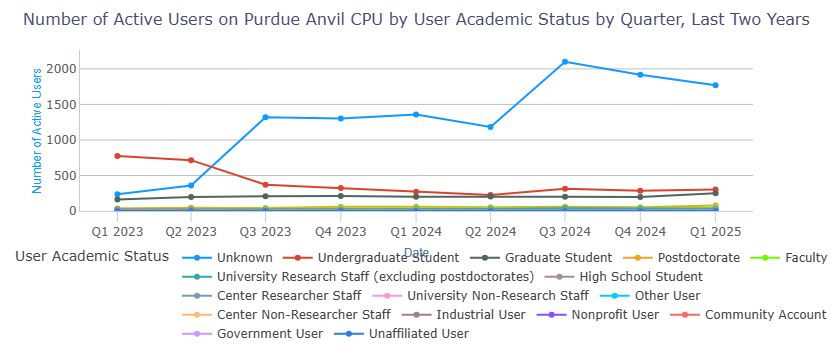

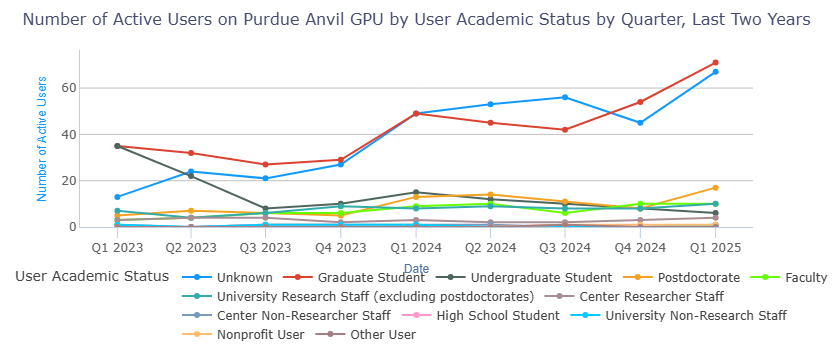

(None, [])

In [37]:
two_year_line_plot_by_quarter(
    y='users',
    resource='Purdue Anvil CPU',
    dimension='academic status',
)

two_year_line_plot_by_quarter(
    y='users',
    resource='Purdue Anvil GPU',
    dimension='academic status',
)

In [39]:
with dw:
    metrics = dw.describe_metrics('Jobs')
display_df_md_table(metrics)

| id                                 | label                                           | description                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
|:-----------------------------------|:------------------------------------------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| utilization                        | ACCESS CPU Utilization (%)                      | The percentage of the ACCESS obligation of a resource that has been utilized by ACCESS jobs.<br/><i> ACCESS CPU Utilization:</i> The ratio of the total CPU hours consumed by ACCESS jobs over a given time period divided by the total CPU hours that the system is contractually required to provide to ACCESS during that period. It does not include non-ACCESS jobs.<br/>It is worth noting that this value is a rough estimate in certain cases where the resource providers don't provide accurate records of their system specifications, over time.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| avg_ace                            | ACCESS Credit Equivalents Charged: Per Job (SU) | The average amount of ACCESS Credit Equivalents charged per compute job.<br/><br/><br/>The ACCESS Credit Equivalent is a measure of how much compute time was used on each resource.<br/>One ACCESS Credit Equivalent is defined as one CPU Hour on SDSC Expanse (an AMD EPYC 7742 based compute resource).<br/>The ACCESS Credit Equivalent allows comparison between usage of node-allocated, core-allocated and GPU-allocated <br/>resources. It also allows a comparison between resources with different compute power per core.<br/>The <a href="https://allocations.access-ci.org/exchange_calculator" target="_blank" rel="noopener noreferrer">ACCESS allocations exchange calculator</a><br/>lists conversion rates between an ACCESS Credit Equivalent and a service unit on a resource.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| total_ace                          | ACCESS Credit Equivalents Charged: Total (SU)   | The total amount of ACCESS Credit Equivalents charged.<br/><br/><br/>The ACCESS Credit Equivalent is a measure of how much compute time was used on each resource.<br/>One ACCESS Credit Equivalent is defined as one CPU Hour on SDSC Expanse (an AMD EPYC 7742 based compute resource).<br/>The ACCESS Credit Equivalent allows comparison between usage of node-allocated, core-allocated and GPU-allocated <br/>resources. It also allows a comparison between resources with different compute power per core.<br/>The <a href="https://allocations.access-ci.org/exchange_calculator" target="_blank" rel="noopener noreferrer">ACCESS allocations exchange calculator</a><br/>lists conversion rates between an ACCESS Credit Equivalent and a service unit on a resource.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| rate_of_usage                      | Allocation Usage Rate (XD SU/Hour)              | The rate of ACCESS allocation usage in XD SUs per hour.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| rate_of_usage_ace                  | Allocation Usage Rate ACEs (SU/Hour)            | The rate of ACCESS allocation usage in ACCESS Credit Equivalents per hour.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| avg_cpu_hours                      | CPU Hours: Per Job                              | The average CPU hours (number of CPU cores x wall time hours) per ACCESS job.<br/>For each job, the CPU usage is aggregated. For example, if a job used 1000 CPUs for one minute, it would be aggregated as 1000 CPU minutes or 16.67 CPU hours.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| total_cpu_hours                    | CPU Hours: Total                                | The total CPU hours (number of CPU cores x wall time hours) used by ACCESS jobs.<br/>For each job, the CPU usage is aggregated. For example, if a job used 1000 CPUs for one minute, it would be aggregated as 1000 CPU minutes or 16.67 CPU hours.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        |
| max_processors                     | Job Size: Max (Core Count)                      | The maximum size ACCESS job in number of cores.<br/><i>Job Size: </i>The total number of processor cores used by a (parallel) job.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| min_processors                     | Job Size: Min (Core Count)                      | The minimum size ACCESS job in number of cores.<br/><i>Job Size: </i>The total number of processor cores used by a (parallel) job.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| normalized_avg_processors          | Job Size: Normalized (% of Total Cores)         | The percentage average size ACCESS job over total machine cores.<br><i>Normalized Job Size: </i>The percentage total number of processor cores used by a (parallel) job over the total number of cores on the machine.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| avg_processors                     | Job Size: Per Job (Core Count)                  | The average job size per ACCESS job.<br><i>Job Size: </i>The number of processor cores used by a (parallel) job.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                           |
| avg_job_size_weighted_by_ace       | Job Size: Weighted By ACEs (Core Count)         | The average job size weighted by charge in ACCESS Credit Equivalents (ACEs). Defined as <br><i>Average Job Size Weighted By ACEs: </i> sum(i = 0 to n){job i core count*job i charge in ACEs}/sum(i =  0 to n){job i charge in ACEs}                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| avg_job_size_weighted_by_cpu_hours | Job Size: Weighted By CPU Hours (Core Count)    | The average ACCESS job size weighted by CPU Hours. Defined as <br><i>Average Job Size Weighted By CPU Hours: </i> sum(i = 0 to n){ job i core count * job i cpu hours}/sum(i =  0 to n){job i cpu hours}                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| avg_job_size_weighted_by_xd_su     | Job Size: Weighted By XD SUs (Core Count)       | The average ACCESS job size weighted by charge in XD SUs. Defined as <br><i>Average Job Size Weighted By XD SUs: </i> sum(i = 0 to n){job i core count*job i charge in xd sus}/sum(i =  0 to n){job i charge in xd sus}                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    |
| avg_nu                             | NUs Charged: Per Job                            | The average amount of NUs charged per ACCESS job.<br/><br/><i>NU - Normalized Units: </i>Roaming allocations are awarded in XSEDE Service Units (SUs). 1 XSEDE SU is defined as one CPU-hour on a Phase-1 DTF cluster. <br/>For usage on a resource that is charged to a Roaming allocation, a normalization factor is applied. The normalization factor is based on<br/>the method historically used to calculate 'Normalized Units' (Cray X-MP-equivalent SUs), which derives from a resource's performance on the HPL<br/>benchmark.<br/><br/><br/>Specifically, 1 Phase-1 DTF SU = 21.576 NUs, and the XD SU conversion factor for a resource is calculated by taking its NU conversion factor<br/>and dividing it by 21.576. The standard formula for calculating a resource's NU conversion factor is: (Rmax * 1000 / 191) / P<br/>where Rmax is the resource's Rmax result on the HPL benchmark in Gflops and P is the number of processors used in the benchmark.<br/>In the absence of an HPL benchmark run, a conversion factor can be agreed upon, based on that of an architecturally similar platform<br/>and scaled according to processor performance differences.<br/><br/><br/>Conversion to Roaming SUs is handled by the XSEDE central accounting system, and RPs are only required to report usage in local SUs for all allocations.<br/><br/><br/>Defining an SU charge for specialized compute resources (such as visualization hardware) or non-compute resources (such as storage) is possible, but there is no XSEDE-wide policy for doing so.    |
| total_nu                           | NUs Charged: Total                              | The total amount of NUs charged by ACCESS jobs.<br/><br/><i>NU - Normalized Units: </i>Roaming allocations are awarded in XSEDE Service Units (SUs). 1 XSEDE SU is defined as one CPU-hour on a Phase-1 DTF cluster.<br/>For usage on a resource that is charged to a Roaming allocation, a normalization factor is applied. The normalization factor is based on <br/>the method historically used to calculate 'Normalized Units' (Cray X-MP-equivalent SUs), which derives from a resource's performance on the HPL <br/>benchmark.<br/><br/><br/>Specifically, 1 Phase-1 DTF SU = 21.576 NUs, and the XD SU conversion factor for a resource is calculated by taking its NU conversion factor <br/>and dividing it by 21.576. The standard formula for calculating a resource's NU conversion factor is: (Rmax * 1000 / 191) / P <br/>where Rmax is the resource's Rmax result on the HPL benchmark in Gflops and P is the number of processors used in the benchmark. <br/>In the absence of an HPL benchmark run, a conversion factor can be agreed upon, based on that of an architecturally similar platform <br/>and scaled according to processor performance differences.<br/><br/><br/>Conversion to Roaming SUs is handled by the XSEDE central accounting system, and RPs are only required to report usage in local SUs for all allocations.<br/><br/><br/>Defining an SU charge for specialized compute resources (such as visualization hardware) or non-compute resources (such as storage) is possible, but there is no XSEDE-wide policy for doing so. |
| avg_node_hours                     | Node Hours: Per Job                             | The average node hours (number of nodes x wall time hours) per ACCESS job.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 |
| total_node_hours                   | Node Hours: Total                               | The total node hours (number of nodes x wall time hours) used by ACCESS jobs.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              |
| active_allocation_count            | Number of Allocations: Active                   | The total number of funded projects that used ACCESS resources.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            |
| active_institution_count           | Number of Institutions: Active                  | The total number of institutions that used ACCESS resources.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| job_count                          | Number of Jobs Ended                            | The total number of ACCESS jobs that ended within the selected duration.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| running_job_count                  | Number of Jobs Running                          | The total number of ACCESS jobs that are running.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          |
| started_job_count                  | Number of Jobs Started                          | The total number of ACCESS jobs that started executing within the selected duration.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       |
| submitted_job_count                | Number of Jobs Submitted                        | The total number of ACCESS jobs that submitted/queued within the selected duration.<i>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     |
| gateway_job_count                  | Number of Jobs via Gateway                      | The total number of ACCESS  jobs submitted through gateways (e.g., via a community user account) that ended within the selected duration.<br/><i>Job: </i>A scheduled process for a computer resource in a batch processing environment.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   |
| active_pi_count                    | Number of PIs: Active                           | The total number of Principal Investigators (PIs) of projects that that used ACCESS resources.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             |
| active_resource_count              | Number of Resources: Active                     | The total number of active ACCESS resources.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               |
| active_person_count                | Number of Users: Active                         | The total number of users that used ACCESS resources.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| expansion_factor                   | User Expansion Factor                           | Gauging ACCESS job-turnaround time, it measures the ratio of wait time and the total time from submission to end of execution.<br/><i>User Expansion Factor = ((wait duration + wall duration) / wall duration). </i>                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      |
| avg_waitduration_hours             | Wait Hours: Per Job                             | The average time, in hours, a ACCESS job waits before execution on the designated resource.<br/><i>Wait Time: </i>Wait time is defined as the linear time between submission of a job by a user until it begins to execute.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| total_waitduration_hours           | Wait Hours: Total                               | The total time, in hours, ACCESS jobs waited before execution on their designated resource.<br/><i>Wait Time: </i>Wait time is defined as the linear time between submission of a job by a user until it begins to execute.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                |
| avg_wallduration_hours             | Wall Hours: Per Job                             | The average time, in hours, a job takes to execute.<br/>In timeseries view mode, the statistic shows the average wall time per job per time period. In aggregate view mode the statistic only includes the job wall hours between the defined time range. The wall hours outside the time range are not included in the calculation.<br /> <i>Wall Time:</i> Wall time is defined as the linear time between start and end time of execution for a particular job.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| total_wallduration_hours           | Wall Hours: Total                               | The total time, in hours, ACCESS jobs took to execute.<br/><i>Wall Time:</i> Wall time is defined as the linear time between start and end time of execution for a particular job.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         |
| avg_su                             | XD SUs Charged: Per Job                         | The average amount of XD SUs charged per ACCESS job.<br/><br/><i>XD SU: </i>1 XSEDE SU is defined as one CPU-hour on a Phase-1 DTF cluster.<br/><br/><i>SU - Service Units: </i>Computational resources on the XSEDE are allocated and charged in service units (SUs). SUs are defined locally on each system, with conversion factors among systems based on HPL benchmark results.<br/><br/><br/>Current TeraGrid supercomputers have complex multi-core and memory hierarchies. Each resource has a specific configuration that determines the number (N) of cores that can be dedicated to a job without slowing the code (and other user and system codes). Each resource defines for its system the minimum number of SUs charged for a job running in the default batch queue, calculated as wallclock runtime multiplied by N. Minimum charges may apply.<br/><br/><br/>Note: The actual charge will depend on the specific requirements of the job (e.g., the mapping of the cores across the machine, or the priority you wish to obtain).<br/><br/><br/>Note 2: The SUs shown here have been normalized against the XSEDE Roaming service. Therefore they are comparable across resources.                                                                                                                                                                                                                                                                                                                                                                      |
| total_su                           | XD SUs Charged: Total                           | The total amount of XD SUs charged by ACCESS jobs.<br/><br/><i>XD SU: </i>1 XSEDE SU is defined as one CPU-hour on a Phase-1 DTF cluster.<br/><br/><i>SU - Service Units: </i>Computational resources on the XSEDE are allocated and charged in service units (SUs). SUs are defined locally on each system, with conversion factors among systems based on HPL benchmark results.<br/><br/><br/>Current TeraGrid supercomputers have complex multi-core and memory hierarchies. Each resource has a specific configuration that determines the number (N) of cores that can be dedicated to a job without slowing the code (and other user and system codes). Each resource defines for its system the minimum number of SUs charged for a job running in the default batch queue, calculated as wallclock runtime multiplied by N. Minimum charges may apply.<br/><br/><br/>Note: The actual charge will depend on the specific requirements of the job (e.g., the mapping of the cores across the machine, or the priority you wish to obtain).<br/><br/><br/>Note 2: The SUs shown here have been normalized against the XSEDE Roaming service. Therefore they are comparable across resources.                                                                                                                                                                                                                                                                                                                                                                        |

## Active User Institutions

### Total

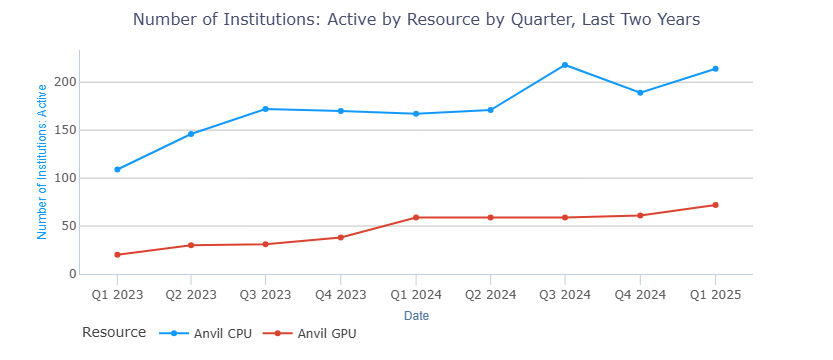

(None, [])

In [41]:
two_year_line_plot_by_quarter(
    y='institutions',
    resource='all',
    dimension=None,
)

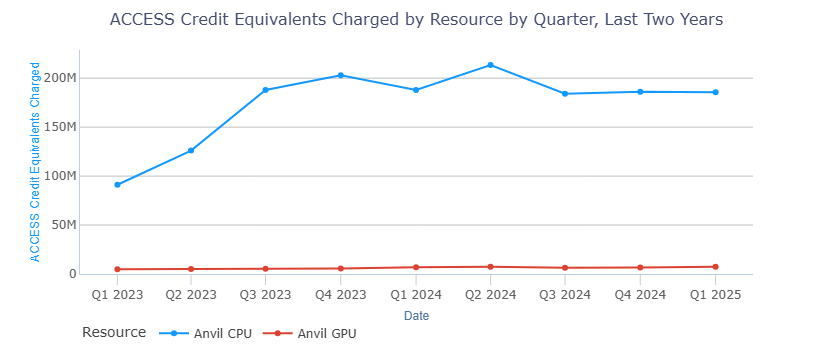

(None, [])

In [42]:
two_year_line_plot_by_quarter(
    y='ace',
    resource='all',
    dimension='pfos',
)

In [43]:
resources = ['Purdue Anvil CPU', 'Purdue Anvil GPU']

with dw:
    for resource in resources:
        
        df_ace_charged = dw.get_data(
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            realm = 'Jobs',
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)',
            dimension = 'Allocation',
            dataset_type = 'aggregate',
            filters = {'Resource': resource},
        )
        
        df_jobs_ran = dw.get_data(
            duration = (QUARTER_START_DATE, QUARTER_END_DATE),
            realm = 'Jobs',
            metric = 'Number of Jobs Running',
            dimension ='Allocation',
            dataset_type ='aggregate',
            filters = {'Resource': resource},
        )
        
        df_all_projects = dw.get_raw_data(
                   duration = (QUARTER_START_DATE,QUARTER_END_DATE),
                   realm = 'Allocations',
                   filters = {'Resource': resource}
        )
        
        active_projects = df_ace_charged.index.tolist()
        
        
        df_active_projects = df_all_projects[df_all_projects['Name'].isin(active_projects)]
        df_active_projects = df_active_projects[['Name', 'Initial Start Date', 'Board Type','Field of Science','Parent Science']]
        df_active_projects = df_active_projects.rename(columns={
            'Board Type': 'Type',
            'Name': 'Title'
        })
        df_active_projects = df_active_projects.sort_values(by='Initial Start Date')
        
        df_active_projects = df_active_projects.groupby(
            ['Title','Field of Science','Parent Science']
        ).agg(
            {'Type': lambda x: ' -> '.join(list(dict.fromkeys(x)))
            }
        )
        
        
        df_active_projects = df_active_projects.reset_index().set_index('Title')
        
        df_active_projects = df_active_projects.join(df_ace_charged)
        df_active_projects = df_active_projects.join(df_jobs_ran)
        
        
        df_active_projects = df_active_projects.rename(columns={
            'Number of Jobs Running':'Number of Jobs',
            'ACCESS Credit Equivalents Charged: Total (SU)':'ACCESS Credit Equivalents Charged'
        })
        
        df_active_projects = df_active_projects.reset_index()
        
        
        df_active_projects[['Charge Number', 'Title']] = df_active_projects['Title'].str.split('-', n=1, expand=True)
        df_active_projects = df_active_projects.set_index('Charge Number')

        

        reorder_columns = ['ACCESS Credit Equivalents Charged',
                           'Number of Jobs',
                           'Type',
                           'Parent Science',
                           'Field of Science',
                           'Title'
                          ]
        df_active_projects = df_active_projects[reorder_columns]

        df_active_projects = df_active_projects.reset_index()

        title = 'ACCESS-Metrics-Report-' + resource.replace(' ', '-') + '-2025-Q1-Projects'

        css = """
        table.dataTable th.dt-type-numeric div.dt-column-header {
            flex-direction: row !important;
        }
        table.dataTable tfoot>tr>th div.dt-column-footer span.dt-column-title input {
            width: 100%
        }
        """
        display(HTML(f'<style>{css}</style>' ''))


        js_code = """
        $.fn.dataTable.ext.type.order['project-type-pre'] = function ( data ) {
  
            access_project_types = ['Explore', 'Discover', 'Accelerate', 'Maximize'];
            custom_sort_order = {};
            rank = 0;
            for (i = 0; i < access_project_types.length; i++) {
                custom_sort_order[access_project_types[i]] = rank++;
                if (i + 1 < access_project_types.length) {
                    custom_sort_order[access_project_types[i] + ' -> ' + access_project_types[i + 1]] = rank++;
                }
            }
          return custom_sort_order[data]; 
        };"""
        
        display(Javascript(js_code))




        

        itables.options.text_in_header_can_be_selected = False

        order = []

        itables.show(
            df_active_projects,
            buttons=[
                'pageLength', 'copyHtml5',
                {"extend": "csvHtml5", "title": title},
                {"extend": "excelHtml5", "title": title},
                "columnsToggle",
            ],
            column_filters= 'footer',
            order=[[1, 'desc']],
            autoWidth=False,
            allow_html=True,
            columnDefs=[{
            "targets": [1],
            "render": itables.JavascriptCode(
                "$.fn.dataTable.render.number(',' , '.' , '2')"
            ),},{"targets": [2],
                 "render": itables.JavascriptCode("$.fn.dataTable.render.number(',', '.',)")
                },{'width': '1px','className': 'dt-left','orderSequence': ['asc', 'desc'] , 'targets': '_all',},
                        {"className": "dt-body-right",'orderSequence': ['desc', 'asc'], "targets": [1, 2]},
                       ])


<IPython.core.display.Javascript object>

Loading ITables v2.4.0 from the internet... (need help?)


<IPython.core.display.Javascript object>

Loading ITables v2.4.0 from the internet... (need help?)


In [4]:

format_str = '%Y-%m-%d'
day_before_two_years_ago_quarter_start_date = (datetime.strptime(TWO_YEARS_AGO_QUARTER_START_DATE, format_str).date() - timedelta(days=1)).strftime(format_str)

print(resource)
with dw:
    active_project1 = dw.get_data(
         realm = 'Jobs',
         duration = ('2015-01-01' , day_before_two_years_ago_quarter_start_date),
         metric = 'Number of Jobs Running', 
         dimension = 'Allocation',
         dataset_type = 'aggregate',
         aggregation_unit='quarter',
         filters = {'Resource': resource},
     )

    active_project2 = dw.get_data(
        realm = 'Jobs',
        duration = (TWO_YEARS_AGO_QUARTER_START_DATE , QUARTER_END_DATE),
        metric = 'Number of Jobs Running', 
        dimension = 'Allocation',
        dataset_type = 'timeseries',
        aggregation_unit='quarter',
        filters = {'Resource': resource},
    )
    
old_projects = active_project1.index.tolist()

active_project2 = active_project2.transpose()
active_project2 = active_project2.reset_index()

active_project2 = active_project2[~active_project2['Allocation'].isin(old_projects)]



num_per_quarter = []
list_of_quarters = active_project2.columns[1:].to_list()

for quarter in list_of_quarters:

    active_rows = active_project2[active_project2[quarter] > 0]
    num_per_quarter.append(len(active_rows))
    active_project2 = active_project2.drop(active_rows.index)


plot = px.line(
    x= list_of_quarters, 
    y= num_per_quarter ,
    
    title="Number of new active projects per quarter in the Last 2 years",
    
)
plot.update_traces(
    hovertemplate='%{y:,.0f}',
    )
plot.update_layout(
    xaxis_tickformat='Q%q %Y',
    hovermode='x unified',
    hoverlabel_namelength=-1,
    )


plot.update_xaxes(title_text='Last 2 years in Quarters')
plot.update_yaxes(title_text='Number of Active Projects')

plot.show()



NameError: name 'datetime' is not defined

,name,pop,lat,lon,text
0,New York,8287238,40.730599,-73.986581,New York <br>Population 8.287238 million
1,Los Angeles,3826423,34.053717,-118.242727,Los Angeles <br>Population 3.826423 million
2,Chicago,2705627,41.875555,-87.624421,Chicago <br>Population 2.705627 million
3,Houston,2129784,29.758938,-95.367697,Houston <br>Population 2.129784 million
4,Philadelphia,1539313,39.952335,-75.163789,Philadelphia <br>Population 1.539313 million
...,...,...,...,...,...
3223,Spanish Fort,7102,30.674913,-87.915272,Spanish Fort <br>Population 0.007102 million
3224,Plaquemine,7102,30.289083,-91.234274,Plaquemine <br>Population 0.007102 million
3225,Milton-Freewater,7102,45.932635,-118.387743,Milton-Freewater <br>Population 0.007102 million
3226,Benton,7096,36.034529,-88.101285,Benton <br>Population 0.007096 million


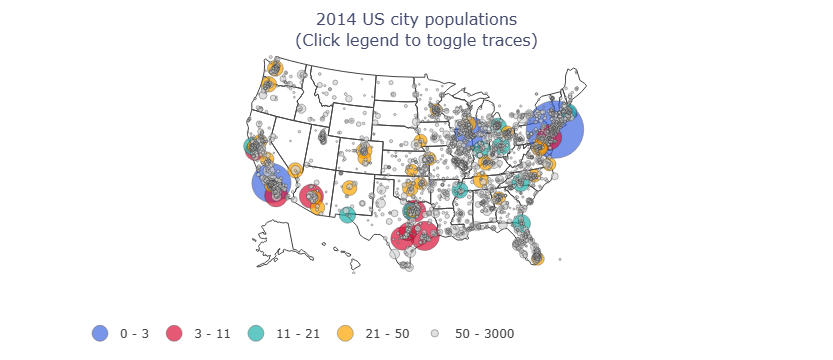

In [117]:
import plotly.graph_objects as go



df = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/2014_us_cities.csv')
df.head()



df['text'] = df['name'] + '<br>Population ' + (df['pop']/1e6).astype(str)+' million'

display(df)
limits = [(0,3),(3,11),(11,21),(21,50),(50,3000)]
colors = ["royalblue","crimson","lightseagreen","orange","lightgrey"]
cities = []
scale = 5000

fig = go.Figure()

for i in range(len(limits)):
    lim = limits[i]
    df_sub = df[lim[0]:lim[1]]
    fig.add_trace(go.Scattergeo(
        locationmode = 'USA-states',
        lon = df_sub['lon'],
        lat = df_sub['lat'],
        text = df_sub['text'],
        marker = dict(
            size = df_sub['pop']/scale,
            color = colors[i],
            line_color='rgb(40,40,40)',
            line_width=0.5,
            sizemode = 'area'
        ),
        name = '{0} - {1}'.format(lim[0],lim[1])))

fig.update_layout(
        title_text = '2014 US city populations<br>(Click legend to toggle traces)',
        showlegend = True,
        geo = dict(
            scope = 'usa',
            landcolor = 'rgb(217, 217, 217)',
        )
    )

fig.show()


In [119]:
df = pd.read_csv('~/Downloads/xdmod-notebooks/user-inst-2025-q1.csv')
df.head()

df = df[df['total_ace'] != 0]

display_df_md_table(df)




|     |   User Institution ID | User Institution Name                                                                   | latitude      | longitude       |   active_person_count |   total_ace |   running_job_count |
|----:|----------------------:|:----------------------------------------------------------------------------------------|:--------------|:----------------|----------------------:|------------:|--------------------:|
|   0 |                    11 | Kennesaw State U - Kennesaw State University                                            | 34.0385060000 | -84.5848150000  |                     1 |      11,126 |                   3 |
|   1 |                    15 | IUPU Fort Wayne - Indiana University-Purdue University Fort Wayne                       | 41.0644740000 | -85.1738570000  |                    18 |       5,211 |                   1 |
|   2 |                    16 | Valparaiso U - Valparaiso University                                                    | 41.4624650000 | -87.0430600000  |                     7 |         533 |                   1 |
|   3 |                    21 | U Mass, Lowell - University of Massachusetts, Lowell                                    | 42.6560000000 | -71.3303120000  |                     8 |   3,779,747 |                  17 |
|   4 |                    28 | U Montana - University of Montana                                                       | 46.8611910000 | -113.9845020000 |                     1 |     742,485 |                   1 |
|   5 |                    32 | Barnard College - Barnard College                                                       | 40.8095190000 | -73.9635510000  |                     2 |           6 |                   1 |
|   6 |                    35 | SUNY Buffalo - SUNY at Buffalo                                                          | 42.9559680000 | -78.8205320000  |                     8 |     453,789 |                  12 |
|   7 |                    41 | St Vincent College - Saint Vincent College                                              | 40.2948870000 | -79.4061660000  |                     1 |         242 |                   4 |
|   8 |                    49 | WV State U - West Virginia State University                                             | 38.3828150000 | -81.7662640000  |                    12 |       1,096 |                   1 |
|   9 |                    57 | Tuskegee U - Tuskegee University                                                        | 32.4305780000 | -85.7039880000  |                     1 |     322,027 |                   1 |
|  10 |                    58 | U Alabama - University of Alabama                                                       | 33.2094380000 | -87.5414930000  |                    10 |   3,199,995 |                 200 |
|  11 |                    59 | U Alabama, Birmingham - University of Alabama, Birmingham                               | 33.5019030000 | -86.8048300000  |                     4 |     279,123 |                  10 |
|  12 |                    60 | U Alabama, Huntsville - University of Alabama, Huntsville                               | 34.7265230000 | -86.6396956000  |                     6 |   4,422,315 |                   2 |
|  13 |                    61 | U South Alabama - University of South Alabama                                           | 30.6965030000 | -88.1796710000  |                     3 |     182,494 |                   1 |
|  14 |                    63 | Arizona State U - Arizona State University                                              | 33.4197750000 | -111.9294500000 |                    22 |   3,079,856 |                  21 |
|  15 |                    64 | U Arizona - University of Arizona                                                       | 32.2316470000 | -110.9566570000 |                    11 |   3,857,873 |                   1 |
|  16 |                    65 | Arkansas State U - Arkansas State University                                            | 35.8428240000 | -90.6802190000  |                     1 |      61,039 |                   8 |
|  17 |                    67 | U Arkansas - University of Arkansas                                                     | 36.0684140000 | -94.1688600000  |                     5 |   4,454,651 |                   1 |
|  18 |                    68 | Caltech - California Institute of Technology                                            | 34.1367810000 | -118.1252660000 |                    39 |  17,555,330 |                  44 |
|  19 |                    70 | CSU-Fullerton - California State University-Fullerton                                   | 33.8805560000 | -117.8852780000 |                     6 |     718,863 |                   1 |
|  20 |                    72 | CSU-Long Beach - California State University-Long Beach                                 | 33.7830220000 | -118.1128580000 |                     1 |         107 |                   1 |
|  21 |                    73 | CSU-Los Angeles - California State University-Los Angeles                               | 34.0666670000 | -118.1677780000 |                    90 |      33,116 |                   3 |
|  22 |                    74 | CSU-Dominguez Hills - California State University-Dominguez Hills                       | 33.8634680000 | -118.2531940000 |                     2 |         196 |                   1 |
|  23 |                    75 | CSU-San Bernardino - California State University-San Bernardino                         | 34.1748019000 | -117.3190430000 |                     9 |         295 |                   1 |
|  24 |                    78 | Cal Poly - California Polytechnic State University, San Luis Obispo                     | 35.3001130000 | -120.6615970000 |                    19 |      69,043 |                   6 |
|  25 |                    79 | CSU-Chico - California State University-Chico                                           | 39.7284640000 | -121.8440200000 |                     8 |      12,376 |                   1 |
|  26 |                    80 | CSU-Fresno - California State University-Fresno                                         | 36.8119810000 | -119.7454270000 |                     5 |      33,079 |                   1 |
|  27 |                    82 | CSU-Sacramento - California State University-Sacramento                                 | 38.5602220000 | -121.4241110000 |                     1 |         321 |                   1 |
|  28 |                    83 | San Diego State U - San Diego State University                                          | 32.8546720000 | -117.2045330000 |                     7 |     263,061 |                   1 |
|  29 |                    85 | San Francisco State U - San Francisco State University                                  | 37.7262772000 | -122.4792744000 |                     1 |          14 |                   1 |
|  30 |                    86 | San Jose State U - San Jose State University                                            | 37.3361450000 | -121.8825780000 |                     3 |         514 |                   1 |
|  31 |                    87 | Sonoma State U - Sonoma State University                                                | 38.3365880000 | -122.6742070000 |                     1 |     140,841 |                  16 |
|  32 |                    90 | Harvey Mudd College - Harvey Mudd College                                               | 34.1057350000 | -117.7068590000 |                    19 |     871,224 |                  14 |
|  33 |                    92 | Pomona College - Pomona College                                                         | 34.0973040000 | -117.7135880000 |                     2 |       2,749 |                   1 |
|  34 |                    94 | Pasadena City College - Pasadena City College                                           | 34.1438940000 | -118.1184960000 |                     1 |         134 |                   2 |
|  35 |                    95 | Salk Institute - Salk Institute for Biological Studies                                  | 32.8872220000 | -117.2461110000 |                     6 |   2,334,007 |                   1 |
|  36 |                    97 | Stanford - Stanford University                                                          | 37.4319850000 | -122.1710710000 |                    26 |  18,374,211 |                   4 |
|  37 |                    98 | Naval Postgrad School - Naval Postgraduate School                                       | 36.5984750000 | -121.8735480000 |                     2 |   1,025,303 |                   1 |
|  38 |                   100 | UC Berkeley - University of California, Berkeley                                        | 37.8754404000 | -122.2455364000 |                   102 |   8,807,942 |                   1 |
|  39 |                   101 | UC Davis - University of California, Davis                                              | 38.5362290000 | -121.7505060000 |                    51 |   7,652,822 |                   1 |
|  40 |                   102 | UC Irvine - University of California, Irvine                                            | 33.6387024000 | -117.8370041000 |                    21 |   1,413,641 |                   5 |
|  41 |                   103 | UCLA - University of California, Los Angeles                                            | 34.0719880000 | -118.4430460000 |                    63 |  23,240,058 |                   2 |
|  42 |                   104 | UC Riverside - University of California, Riverside                                      | 33.9701736000 | -117.3293277000 |                    23 |   4,584,508 |                   3 |
|  43 |                   105 | UC San Diego - University of California, San Diego                                      | 32.8751050000 | -117.2397840000 |                   228 |  18,483,625 |                   1 |
|  44 |                   107 | UC Santa Barbara - University of California, Santa Barbara                              | 34.4148210000 | -119.8395540000 |                   101 |  15,775,622 |                   2 |
|  45 |                   108 | UC Santa Cruz - University of California, Santa Cruz                                    | 37.0000000000 | -122.0600000000 |                    23 |     791,588 |                   4 |
|  46 |                   109 | U San Francisco - University of San Francisco                                           | 37.7758770000 | -122.4506580000 |                     1 |      32,385 |                   1 |
|  47 |                   111 | USC - University of Southern California                                                 | 34.0185030000 | -118.2833010000 |                    18 |   1,410,053 |                   1 |
|  48 |                   112 | U Pacific - University of the Pacific                                                   | 37.9768720000 | -121.3158540000 |                     6 |     168,847 |                   1 |
|  49 |                   113 | Westmont College - Westmont College                                                     | 34.4497790000 | -119.6601060000 |                     5 |      61,946 |                   1 |
|  50 |                   114 | Colorado College - Colorado College                                                     | 38.8467270000 | -104.8238590000 |                     1 |           1 |                   1 |
|  51 |                   115 | Colorado Sch of Mines - Colorado School of Mines                                        | 39.7508590000 | -105.2223990000 |                    18 |   1,180,572 |                  11 |
|  52 |                   116 | U Northern Colorado - University of Northern Colorado                                   | 40.4037410000 | -104.7030260000 |                     1 |      17,513 |                   4 |
|  53 |                   117 | Colorado State U - Colorado State University                                            | 40.5746950000 | -105.0808240000 |                    23 |   2,472,951 |                  23 |
|  54 |                   118 | Fort Lewis College - Fort Lewis College                                                 | 37.2752250000 | -107.8708190000 |                     1 |          94 |                   2 |
|  55 |                   120 | Metro State U Denver - Metropolitan State University of Denver                          | 39.7420320000 | -105.0036070000 |                     6 |         138 |                   1 |
|  56 |                   124 | U New Haven - University of New Haven                                                   | 41.2912990000 | -72.9614410000  |                     1 |         118 |                   1 |
|  57 |                   126 | Southern Conn State U - Southern Connecticut State University                           | 41.3326280000 | -72.9465900000  |                     1 |     466,155 |                   1 |
|  58 |                   130 | Yale U - Yale University                                                                | 41.3093750000 | -72.9294520000  |                    46 |   3,194,947 |                   1 |
|  59 |                   131 | UDEL - University of Delaware                                                           | 38.7799740000 | -75.1629440000  |                    29 |  18,289,014 |                   1 |
|  60 |                   134 | Gallaudet U - Gallaudet University                                                      | 38.9054580000 | -76.9950670000  |                     1 |     258,858 |                   2 |
|  61 |                   135 | George Washington U - George Washington University                                      | 38.9008460000 | -77.0475780000  |                     8 |   1,501,614 |                   2 |
|  62 |                   136 | Georgetown U - Georgetown University                                                    | 38.9072870000 | -77.0733840000  |                     7 |   1,377,901 |                   1 |
|  63 |                   137 | Howard U - Howard University                                                            | 38.9212171000 | -77.0204624000  |                    20 |   5,321,869 |                   1 |
|  64 |                   140 | Florida Atlantic U - Florida Atlantic University                                        | 26.3718100000 | -80.1013310000  |                     2 |       6,028 |                   1 |
|  65 |                   141 | Florida State U - Florida State University                                              | 28.2806600000 | -82.6656080000  |                    13 |   1,988,988 |                  12 |
|  66 |                   143 | U Florida - University of Florida                                                       | 29.6474490000 | -82.3393920000  |                    12 |   6,664,893 |                   1 |
|  67 |                   144 | U Miami - University of Miami                                                           | 25.7173947000 | -80.2781262000  |                    16 |   2,298,967 |                   3 |
|  68 |                   145 | U South Florida - University of South Florida                                           | 28.0618100000 | -82.4138550000  |                     3 |     187,620 |                   1 |
|  69 |                   147 | Clark Atlanta U - Clark Atlanta University                                              | 33.7540100000 | -84.4097600000  |                     3 |     382,819 |                  24 |
|  70 |                   148 | Columbus State U - Columbus State University                                            | 32.5022790000 | -84.9415790000  |                     1 |      11,402 |                   1 |
|  71 |                   150 | Emory U - Emory University                                                              | 33.7911110000 | -84.3233330000  |                     6 |      15,182 |                 778 |
|  72 |                   152 | Georgia State U - Georgia State University                                              | 33.7537270000 | -84.3847000000  |                     9 |     239,154 |                   1 |
|  73 |                   154 | Morehouse College - Morehouse College                                                   | 33.7482450000 | -84.4162030000  |                     2 |          28 |                   1 |
|  74 |                   157 | U Georgia - University of Georgia                                                       | 33.9567460000 | -83.3748190000  |                     2 |      40,913 |                   1 |
|  75 |                   159 | U Hawaii, Manoa - University of Hawaii, Manoa                                           | 21.2963600000 | -157.8212160000 |                     8 |   1,372,297 |                   1 |
|  77 |                   167 | Eastern Illinois U - Eastern Illinois University                                        | 39.4836410000 | -88.1752210000  |                     1 |           3 |                  50 |
|  78 |                   170 | IIT - Illinois Institute of Technology                                                  | 41.8344300000 | -87.6287070000  |                    18 |   2,491,374 |                   2 |
|  79 |                   171 | Illinois State U - Illinois State University                                            | 37.9363900000 | -88.6094400000  |                    28 |      10,711 |                   1 |
|  80 |                   173 | Lake Forest College - Lake Forest College                                               | 42.2499080000 | -87.8289160000  |                     1 |           8 |                   1 |
|  81 |                   174 | Loyola U Chicago - Loyola University Chicago                                            | 41.8971690000 | -87.6237740000  |                     9 |     561,223 |                   1 |
|  82 |                   177 | Northern Illinois U - Northern Illinois University                                      | 41.9332790000 | -88.7652790000  |                     1 |       8,792 |                   2 |
|  83 |                   178 | Northwestern U - Northwestern University                                                | 42.0565190000 | -87.6752220000  |                    28 |   9,194,518 |                   1 |
|  84 |                   180 | SIU Carbondale - Southern Illinois University, Carbondale                               | 37.7101910000 | -89.2172650000  |                     1 |       1,632 |                   6 |
|  85 |                   183 | U Chicago - University of Chicago                                                       | 41.7900510000 | -87.5988910000  |                    40 |  13,244,233 |                   1 |
|  86 |                   184 | UIUC - University of Illinois at Urbana-Champaign                                       | 40.1075210000 | -88.2271690000  |                   843 |  84,727,638 |                   1 |
|  87 |                   185 | U Illinois, Chicago - University of Illinois at Chicago                                 | 41.8718320000 | -87.6482740000  |                    31 |   3,495,818 |                   1 |
|  88 |                   186 | Western Illinois U - Western Illinois University                                        | 40.4654290000 | -90.6861050000  |                     2 |      13,578 |                   1 |
|  89 |                   188 | Ball State U - Ball State University                                                    | 40.1982660000 | -85.4089890000  |                     5 |         555 |                   1 |
|  90 |                   192 | IUPUI - Indiana University-Purdue University Indianapolis                               | 39.7732569000 | -86.1764475000  |                    28 |       4,391 |                   4 |
|  91 |                   194 | U Notre Dame - University of Notre Dame                                                 | 41.6968370000 | -86.2375120000  |                    16 |     161,621 |                   2 |
|  92 |                   195 | Wabash College - Wabash College                                                         | 38.4291070000 | -87.7814360000  |                     2 |          33 |                   1 |
|  93 |                   198 | Iowa State U - Iowa State University                                                    | 42.0231620000 | -93.6464300000  |                    32 |   5,268,892 |                   1 |
|  94 |                   201 | U Northern Iowa - University of Northern Iowa                                           | 42.5144400000 | -92.4599130000  |                     1 |      93,074 |                   1 |
|  95 |                   202 | U Iowa - University of Iowa                                                             | 41.6618875000 | -91.5462877000  |                    22 |       6,491 |                   2 |
|  96 |                   205 | Kansas State U - Kansas State University                                                | 39.1886580000 | -96.5810420000  |                     1 |           1 |                   1 |
|  97 |                   209 | U Louisville - University of Louisville                                                 | 38.2175100000 | -85.7611510000  |                     5 |     219,364 |                   5 |
|  98 |                   213 | U New Orleans - University of New Orleans                                               | 29.9541680000 | -90.0727850000  |                     1 |     184,969 |                   5 |
|  99 |                   216 | Tulane U - Tulane University                                                            | 29.9353880000 | -90.1226750000  |                     5 |   1,977,646 |                   1 |
| 100 |                   217 | Xavier U - Xavier University of Louisiana                                               | 29.9652190000 | -90.1069940000  |                     3 |      29,871 |                   1 |
| 101 |                   221 | U Maine - University of Maine                                                           | 44.8975300000 | -68.6660230000  |                     2 |     174,397 |                   1 |
| 102 |                   222 | Bowie State U - Bowie State University                                                  | 39.0179880000 | -76.7628970000  |                     5 |      19,906 |                  15 |
| 103 |                   225 | Johns Hopkins U - Johns Hopkins University                                              | 39.3291480000 | -76.6205250000  |                    22 |   5,511,894 |                   4 |
| 104 |                   228 | Morgan State U - Morgan State University                                                | 39.3460266000 | -76.5827767000  |                     1 |         256 |                   1 |
| 105 |                   229 | U Maryland - University of Maryland, College Park                                       | 38.9908487000 | -76.9441410000  |                    15 |   2,468,985 |                   1 |
| 106 |                   230 | U Maryland, Baltimore - University of Maryland, Baltimore                               | 39.2553811000 | -76.7076768000  |                     2 |          14 |                   1 |
| 107 |                   231 | U Maryland, Baltimore Co - University of Maryland, Baltimore County                     | 39.2553811000 | -76.7076768000  |                     1 |      66,939 |                   6 |
| 108 |                   234 | Merrimack College - Merrimack College                                                   | 42.6716200000 | -71.1223400000  |                     1 |      42,211 |                   3 |
| 109 |                   235 | Boston College - Boston College                                                         | 42.3496340000 | -71.0996880000  |                     1 |      55,594 |                   1 |
| 110 |                   236 | Boston U - Boston University                                                            | 42.3496340000 | -71.0996880000  |                    10 |   1,650,816 |                  11 |
| 111 |                   237 | Brandeis U - Brandeis University                                                        | 42.3662990000 | -71.2578590000  |                     8 |   9,063,890 |                   2 |
| 112 |                   238 | Clark U - Clark University                                                              | 42.2509770000 | -71.8231690000  |                     1 |      19,364 |                   2 |
| 113 |                   240 | Harvard U - Harvard University                                                          | 42.3800977000 | -71.1166286000  |                    14 |   2,885,600 |                  18 |
| 114 |                   243 | MIT - Massachusetts Institute of Technology                                             | 42.3605390000 | -71.0900740000  |                    79 |  23,226,629 |                   1 |
| 115 |                   245 | Northeastern U - Northeastern University                                                | 42.3391030000 | -71.0879910000  |                    53 |   3,577,111 |                   1 |
| 116 |                   247 | Smith College - Smith College                                                           | 42.3178320000 | -72.6387990000  |                     1 |           1 |                   1 |
| 117 |                   248 | U Mass, Dartmouth - University of Massachusetts, Dartmouth                              | 41.6289670000 | -71.0063390000  |                    40 |   7,099,599 |                   2 |
| 118 |                   250 | Tufts U - Tufts University                                                              | 42.4070050000 | -71.1193120000  |                     9 |     306,824 |                   1 |
| 119 |                   251 | U Mass, Amherst - University of Massachusetts, Amherst                                  | 42.3948500000 | -72.5220210000  |                     3 |      30,781 |                   1 |
| 120 |                   255 | WPI - Worcester Polytechnic Institute                                                   | 42.2729940000 | -71.8106890000  |                     9 |     423,422 |                   2 |
| 121 |                   256 | Calvin College - Calvin College                                                         | 42.9311880000 | -85.5879410000  |                     1 |           5 |                   1 |
| 122 |                   257 | Central Michigan U - Central Michigan University                                        | 43.5898020000 | -84.7774900000  |                     1 |         833 |                   1 |
| 123 |                   262 | Michigan State U - Michigan State University                                            | 42.4409920000 | -84.0254060000  |                    23 |  19,646,268 |                   1 |
| 124 |                   263 | Michigan Tech - Michigan Technological University                                       | 47.1188250000 | -88.5472810000  |                     3 |     410,088 |                   2 |
| 125 |                   265 | U Detroit Mercy - University of Detroit Mercy                                           | 42.4125590000 | -83.1397140000  |                    24 |      33,134 |                   1 |
| 126 |                   267 | Wayne State U - Wayne State University                                                  | 42.3219680000 | -83.2358290000  |                     3 |     126,952 |                   1 |
| 127 |                   268 | W Michigan U - Western Michigan University                                              | 42.2831778000 | -85.6152186000  |                     1 |           0 |                   2 |
| 128 |                   274 | Mississippi State U - Mississippi State University                                      | 33.4537470000 | -88.7900490000  |                     3 |     200,358 |                   1 |
| 129 |                   280 | U Missouri, Columbia - University of Missouri, Columbia                                 | 38.9470820000 | -92.3287550000  |                     8 |   1,644,673 |                   1 |
| 130 |                   281 | Missouri S&T - Missouri University of Science and Technology                            | 37.9536140000 | -91.7770340000  |                     5 |     679,596 |                   7 |
| 131 |                   282 | U Missouri, Kansas City - University of Missouri, Kansas City                           | 39.0375780000 | -94.5791080000  |                     7 |     444,652 |                   1 |
| 132 |                   284 | Washington U - Washington University in St. Louis                                       | 38.6479700000 | -90.3047800000  |                    19 |   3,112,556 |                   1 |
| 133 |                   285 | Montana State U - Montana State University                                              | 45.6665470000 | -111.0481020000 |                     4 |     346,584 |                   2 |
| 134 |                   290 | U Nebraska, Lincoln - University of Nebraska, Lincoln                                   | 40.8180330000 | -96.7015370000  |                     3 |     471,746 |                   2 |
| 135 |                   292 | UNLV - University of Nevada, Las Vegas                                                  | 36.1082300000 | -115.1396100000 |                     8 |     598,648 |                   1 |
| 136 |                   293 | Dartmouth College - Dartmouth College                                                   | 43.7050910000 | -72.2886030000  |                     2 |     445,376 |                   2 |
| 137 |                   294 | U New Hampshire - University of New Hampshire                                           | 43.1362410000 | -70.9296220000  |                     2 |     451,755 |                   1 |
| 138 |                   299 | NJIT - New Jersey Institute of Technology                                               | 40.7432140000 | -74.1762580000  |                    20 |   2,063,132 |                   1 |
| 139 |                   301 | Princeton U - Princeton University                                                      | 40.3440340000 | -74.6569130000  |                    21 |  22,321,559 |                   2 |
| 140 |                   305 | Stevens Inst of Tech - Stevens Institute of Technology                                  | 40.7460800000 | -74.0251970000  |                    16 |   1,124,513 |                   5 |
| 141 |                   307 | New Mexico Highlands U - New Mexico Highlands University                                | 35.5946160000 | -105.2189140000 |                     1 |     139,610 |                   1 |
| 142 |                   308 | New Mexico Tech - New Mexico Institute of Mining and Technology                         | 34.0648450000 | -106.9031940000 |                     4 |     326,293 |                   1 |
| 143 |                   309 | NM State U - New Mexico State University                                                | 32.2829890000 | -106.7487540000 |                    21 |   1,385,575 |                   1 |
| 144 |                   310 | U New Mexico - University of New Mexico                                                 | 35.0819280000 | -106.6190020000 |                    37 |     244,255 |                   5 |
| 145 |                   312 | CUNY - City University of New York                                                      | 40.8204940000 | -73.9483060000  |                     7 |     159,153 |                   1 |
| 146 |                   313 | CUNY Brooklyn College - CUNY Brooklyn College                                           | 40.5770160000 | -73.9352473000  |                     3 |     159,102 |                   2 |
| 147 |                   314 | CUNY City College - CUNY The City College of New York                                   | 40.8166412000 | -73.9514121000  |                     3 |     521,645 |                  71 |
| 148 |                   315 | CUNY Hunter College - CUNY Hunter College                                               | 40.7690240000 | -73.9651630000  |                     4 |       8,914 |                   1 |
| 149 |                   317 | Clarkson U - Clarkson University                                                        | 44.6637080000 | -74.9785450000  |                    15 |     182,372 |                   2 |
| 150 |                   320 | Columbia U - Columbia University in the City of New York                                | 40.8082240000 | -73.9618890000  |                    67 |  53,777,474 |                   5 |
| 151 |                   321 | Cooper Union College - Cooper Union College                                             | 40.8765649000 | -77.8367282000  |                     1 |      25,954 |                   3 |
| 152 |                   325 | Ithaca College - Ithaca College                                                         | 42.4216700000 | -76.5010820000  |                     2 |          55 |                   1 |
| 153 |                   327 | Manhattan College - Manhattan College                                                   | 40.8901790000 | -73.9019880000  |                     3 |     444,148 |                   6 |
| 154 |                   328 | NYU - New York University                                                               | 40.7294270000 | -73.9973180000  |                    23 |     459,386 |                   1 |
| 155 |                   330 | RPI - Rensselaer Polytechnic Institute                                                  | 42.7300000000 | -73.6775000000  |                    16 |   2,145,867 |                   1 |
| 156 |                   332 | RIT - Rochester Institute of Technology                                                 | 43.0839390000 | -77.6761910000  |                    14 |   4,151,695 |                   2 |
| 157 |                   333 | Rockefeller U - Rockefeller University                                                  | 40.7626054000 | -73.9554531000  |                     1 |      42,908 |                   1 |
| 158 |                   334 | Skidmore College - Skidmore College                                                     | 43.0987130000 | -73.7843810000  |                     9 |         150 |                   3 |
| 159 |                   338 | SUNY Binghamton - SUNY at Binghamton                                                    | 42.1337750000 | -75.9626830000  |                    31 |   7,239,099 |                   1 |
| 160 |                   339 | SUNY Downstate Med Ctr - SUNY Downstate Health Sciences University                      | 40.6548290000 | -73.9441870000  |                     5 |      98,837 |                  10 |
| 161 |                   349 | SUNY ESF - SUNY College of Environmental Science and Forestry                           | 43.0339830000 | -76.1392230000  |                     1 |          12 |                   1 |
| 162 |                   355 | Union College - Union College                                                           | 42.8151460000 | -73.9305130000  |                     1 |     419,991 |                   4 |
| 163 |                   357 | U Rochester - University of Rochester                                                   | 43.1206800000 | -77.6266790000  |                     4 |   5,387,995 |                   2 |
| 164 |                   361 | NC A&T State U - North Carolina A&T State University                                    | 36.0778870000 | -79.7708780000  |                     4 |     274,907 |                   2 |
| 165 |                   365 | Duke U - Duke University                                                                | 36.0005190000 | -78.9388620000  |                    10 |     664,580 |                   1 |
| 166 |                   367 | Fayetteville State U - Fayetteville State University                                    | 35.0714220000 | -78.8941390000  |                     6 |       6,266 |                   1 |
| 167 |                   369 | UNC Pembroke - University of North Carolina, Pembroke                                   | 34.6899580000 | -79.2007760000  |                     2 |       8,505 |                   2 |
| 168 |                   371 | NC State U - North Carolina State University                                            | 35.1374140000 | -78.8752370000  |                    21 |   2,231,250 |                   3 |
| 169 |                   372 | UNC - University of North Carolina, Chapel Hill                                         | 35.9138430000 | -79.0506010000  |                    11 |   3,131,209 |                   1 |
| 170 |                   373 | UNC Charlotte - University of North Carolina, Charlotte                                 | 35.3008330000 | -80.7381150000  |                     3 |      41,034 |                   2 |
| 171 |                   374 | UNC Greensboro - University of North Carolina, Greensboro                               | 36.0778870000 | -79.7708780000  |                     1 |         144 |                   1 |
| 172 |                   379 | CWRU - Case Western Reserve University                                                  | 41.5043270000 | -81.6095760000  |                     9 |     325,545 |                   3 |
| 173 |                   381 | Cleveland State U - Cleveland State University                                          | 41.5091257000 | -81.6089873000  |                     1 |      67,377 |                   3 |
| 174 |                   387 | Oberlin College - Oberlin College                                                       | 41.2929610000 | -82.2218300000  |                     2 |     260,470 |                   2 |
| 175 |                   389 | U Toledo - University of Toledo                                                         | 41.6585890000 | -83.6143270000  |                     1 |     183,586 |                   1 |
| 176 |                   390 | Youngstown State U - Youngstown State University                                        | 41.1067590000 | -80.6466740000  |                    34 |      24,307 |                   1 |
| 177 |                   393 | Oregon State U - Oregon State University                                                | 44.5641010000 | -123.2750430000 |                    11 |   6,014,339 |                   1 |
| 178 |                   394 | Portland State U - Portland State University                                            | 45.5115660000 | -122.6858080000 |                     4 |      80,386 |                   1 |
| 179 |                   395 | Reed College - Reed College                                                             | 45.4820170000 | -122.6326040000 |                     3 |   1,131,747 |                   1 |
| 180 |                   396 | U Oregon - University of Oregon                                                         | 44.0438730000 | -123.0727500000 |                     1 |       5,479 |                  10 |
| 181 |                   397 | Allegheny College - Allegheny College                                                   | 41.6481420000 | -80.1459590000  |                     3 |      21,973 |                   1 |
| 182 |                   399 | Bucknell U - Bucknell University                                                        | 40.9568190000 | -76.8876930000  |                     2 |       3,722 |                   1 |
| 183 |                   400 | CMU - Carnegie Mellon University                                                        | 40.4437580000 | -79.9435540000  |                   678 |  68,503,184 |                   1 |
| 184 |                   402 | Chatham U - Chatham University                                                          | 40.4491050000 | -79.9258120000  |                     5 |     139,694 |                   1 |
| 185 |                   404 | Drexel U - Drexel University                                                            | 39.9545200000 | -75.1886500000  |                    19 |     247,165 |                   8 |
| 186 |                   411 | Haverford College - Haverford College                                                   | 40.0104490000 | -75.3058040000  |                     1 |         591 |                   2 |
| 187 |                   412 | Thomas Jefferson U - Thomas Jefferson University                                        | 39.9480960000 | -75.1586760000  |                     1 |     307,017 |                 805 |
| 188 |                   415 | Lehigh U - Lehigh University                                                            | 40.6066550000 | -75.3806480000  |                     9 |     567,469 |                   1 |
| 189 |                   425 | Slippery Rock U - Slippery Rock University                                              | 41.0616740000 | -80.0453920000  |                     1 |           5 |                   1 |
| 190 |                   429 | Swarthmore College - Swarthmore College                                                 | 39.9058700000 | -75.3548920000  |                     4 |         953 |                   3 |
| 191 |                   430 | Temple U - Temple University                                                            | 39.9807070000 | -75.1557260000  |                    11 |   8,699,227 |                   2 |
| 192 |                   431 | U Pennsylvania - University of Pennsylvania                                             | 39.9521970000 | -75.1918490000  |                    43 |   3,012,234 |                   2 |
| 193 |                   433 | Ursinus College - Ursinus College                                                       | 40.1945420000 | -75.4570030000  |                     1 |     381,841 |                   1 |
| 194 |                   434 | Villanova U - Villanova University                                                      | 40.0362280000 | -75.3416410000  |                    11 |     119,826 |                   3 |
| 195 |                   438 | Brown U - Brown University                                                              | 41.8261630000 | -71.4032470000  |                    17 |     266,809 |                   1 |
| 196 |                   439 | U Rhode Island - University of Rhode Island                                             | 41.4846450000 | -71.5254950000  |                     4 |   1,061,682 |                   1 |
| 197 |                   442 | Med U of SC - Medical University of South Carolina                                      | 32.7871210000 | -79.9525910000  |                     1 |      39,926 |                   2 |
| 198 |                   446 | SD State U - South Dakota State University                                              | 42.7860350000 | -96.9253400000  |                     1 |         292 |                   1 |
| 199 |                   447 | E Tenn State U - East Tennessee State University                                        | 35.9530440000 | -83.9268180000  |                    20 |      15,795 |                   2 |
| 200 |                   449 | Middle Tenn State U - Middle Tennessee State University                                 | 35.8432910000 | -86.3701410000  |                    43 |     226,327 |                   5 |
| 201 |                   452 | Tennessee Tech - Tennessee Technological University                                     | 35.9812420000 | -85.0038110000  |                     2 |          55 |                   1 |
| 202 |                   453 | NICS - University of Tennessee, Knoxville                                               | 35.9496697000 | -83.9294330000  |                    20 |   4,868,958 |                   1 |
| 203 |                   455 | Vanderbilt U - Vanderbilt University                                                    | 36.1418890000 | -86.7986760000  |                    10 |     756,348 |                   1 |
| 204 |                   456 | Texas A&M Commerce - Texas A&M University, Commerce                                     | 33.2447960000 | -95.9114550000  |                     1 |          49 |                   1 |
| 205 |                   457 | UT Dallas - University of Texas at Dallas                                               | 32.9878400000 | -96.7506920000  |                    19 |   2,742,766 |                   1 |
| 206 |                   458 | Lamar U - Lamar University                                                              | 30.0424740000 | -94.0725350000  |                     4 |       1,567 |                   3 |
| 207 |                   459 | U North Texas - University of North Texas                                               | 33.2113630000 | -97.1467300000  |                    10 |     358,928 |                   2 |
| 208 |                   460 | UT Rio Grande Valley - University of Texas Rio Grande Valley                            | 32.2755210000 | -106.7355870000 |                     4 |     112,572 |                   2 |
| 209 |                   461 | Rice U - Rice University                                                                | 29.7180610000 | -95.4029090000  |                    21 |   7,478,493 |                   1 |
| 210 |                   463 | S Methodist U - Southern Methodist University                                           | 32.8441140000 | -96.7848740000  |                     1 |       1,830 |                   2 |
| 211 |                   465 | Prairie View A&M - Prairie View A&M University                                          | 30.6186470000 | -96.3360510000  |                    34 |     209,446 |                   1 |
| 212 |                   467 | TAMU - Texas A&M University                                                             | 30.6186470000 | -96.3360510000  |                    78 |   8,555,009 |                   1 |
| 213 |                   469 | Texas A&M Kingsville - Texas A&M University, Kingsville                                 | 27.5257060000 | -97.8824400000  |                     2 |         270 |                   2 |
| 214 |                   470 | Texas Southern U - Texas Southern University                                            | 29.7223280000 | -95.3588740000  |                     2 |         513 |                   1 |
| 215 |                   471 | Texas Tech U - Texas Tech University                                                    | 33.5923280000 | -101.8963480000 |                    14 |  22,511,268 |                   1 |
| 216 |                   473 | U Houston - University of Houston                                                       | 29.7214300000 | -95.3418530000  |                    11 |     390,955 |                   2 |
| 217 |                   474 | UT Arlington - University of Texas at Arlington                                         | 32.7293990000 | -97.1151790000  |                    84 |   6,104,495 |                   4 |
| 218 |                   476 | TACC - University of Texas at Austin                                                    | 30.2857580000 | -97.7358800000  |                    65 |  15,674,222 |                   4 |
| 219 |                   477 | UT El Paso - University of Texas at El Paso                                             | 31.8368720000 | -106.5165250000 |                   137 |     321,709 |                  12 |
| 220 |                   479 | U Utah - University of Utah                                                             | 40.7652220000 | -111.8442520000 |                    13 |   4,144,632 |                   2 |
| 221 |                   483 | U Vermont - University of Vermont                                                       | 44.4797940000 | -73.1959240000  |                     2 |      33,003 |                   5 |
| 222 |                   487 | ODU - Old Dominion University                                                           | 36.8899770000 | -76.3046640000  |                     1 |       1,906 |                   1 |
| 223 |                   492 | U Virginia - University of Virginia                                                     | 38.0356050000 | -78.5060260000  |                     9 |  12,237,241 |                   1 |
| 224 |                   494 | George Mason U - George Mason University                                                | 38.8298280000 | -77.3072230000  |                     9 |   1,641,357 |                   1 |
| 225 |                   495 | Virginia Tech - Virginia Polytechnic Institute and State University                     | 37.2284270000 | -80.4235160000  |                    11 |     439,251 |                   4 |
| 226 |                   500 | U Washington - University of Washington                                                 | 47.6539100000 | -122.3061790000 |                    52 |   4,607,440 |                   1 |
| 227 |                   501 | Washington State U - Washington State University                                        | 46.7263380000 | -117.1678200000 |                     8 |   1,391,492 |                   7 |
| 228 |                   504 | Marshall U - Marshall University                                                        | 38.4234910000 | -82.4291130000  |                    13 |       3,122 |                   1 |
| 229 |                   505 | WVU Tech - West Virginia University Institute of Technology                             | 38.1795640000 | -81.3366900000  |                     1 |     181,769 |                   1 |
| 230 |                   506 | West Virginia U - West Virginia University                                              | 39.6346820000 | -79.9541130000  |                    14 |   6,041,835 |                 204 |
| 231 |                   510 | Marquette U - Marquette University                                                      | 43.0383520000 | -87.9275330000  |                     1 |      22,360 |                   1 |
| 232 |                   514 | U Wisconsin-Madison - University of Wisconsin-Madison                                   | 43.0758710000 | -89.3999270000  |                    47 |  23,272,012 |                   1 |
| 233 |                   515 | U Wisconsin-Milwaukee - University of Wisconsin-Milwaukee                               | 43.0757780000 | -87.8820480000  |                     2 |      93,803 |                   3 |
| 234 |                   521 | U Wisconsin-Whitewater - University of Wisconsin-Whitewater                             | 42.8354490000 | -88.7417960000  |                     1 |      31,998 |                   2 |
| 235 |                   524 | UPR Mayaguez - University of Puerto Rico, Mayaguez                                      | 18.2094440000 | -67.1416670000  |                     4 |      99,563 |                   1 |
| 236 |                   525 | U Central Florida - University of Central Florida                                       | 28.6023120000 | -81.2002230000  |                    45 |   1,167,940 |                   1 |
| 237 |                   527 | Weill Cornell Med College - Weill Cornell Medical College                               | 40.7640470000 | -73.9550280000  |                     4 |   1,433,968 |                   1 |
| 238 |                   528 | CUNY Baruch College - CUNY Baruch College                                               | 40.7389660000 | -73.9846090000  |                     6 |     116,847 |                   3 |
| 239 |                   530 | Oregon Health & Sci U - Oregon Health and Science University                            | 45.4996570000 | -122.6852210000 |                     1 |         182 |                   2 |
| 240 |                   531 | Baylor College of Med - Baylor College of Medicine                                      | 29.7102270000 | -95.3966040000  |                     4 |     284,287 |                   1 |
| 241 |                   534 | U Tenn Health Sci Ctr - University of Tennessee Health Science Center                   | 35.1385380000 | -90.0337300000  |                     1 |          16 |                   1 |
| 242 |                   535 | CU Denver - University of Colorado, Denver                                              | 39.6729875000 | -104.9651706000 |                     1 |     185,119 |                   5 |
| 243 |                   540 | U Nebraska, Med Ctr - University of Nebraska Medical Center                             | 41.2560310000 | -95.9757810000  |                     1 |      40,031 |                   1 |
| 244 |                   541 | Baylor U - Baylor University                                                            | 31.5487300000 | -97.1178620000  |                     9 |   1,668,885 |                   1 |
| 245 |                   542 | CUNY Lehman College - CUNY Lehman College                                               | 40.8750440000 | -73.8928670000  |                     2 |     214,483 |                  42 |
| 246 |                   543 | Mt Sinai Sch of Med - Icahn School of Medicine at Mount Sinai                           | 40.7894750000 | -73.9537810000  |                     1 |     110,862 |                   8 |
| 247 |                   545 | UPR Rio Piedras - University of Puerto Rico, Rio Piedras                                | 18.4027780000 | -66.0500000000  |                     1 |         217 |                   1 |
| 248 |                   553 | U Tenn System - University of Tennessee System                                          | 36.1339070000 | -86.7484370000  |                     1 |      66,354 |                   1 |
| 249 |                   557 | Auburn U - Auburn University                                                            | 32.6020220000 | -85.4860190000  |                    10 |   2,638,331 |                   2 |
| 250 |                   558 | Colorado-Boulder - University of Colorado, Boulder                                      | 40.0051710000 | -105.2663940000 |                    32 |   4,626,353 |                   1 |
| 251 |                   559 | U Connecticut - University of Connecticut                                               | 41.8079550000 | -72.2567390000  |                    13 |     834,820 |                   3 |
| 252 |                   560 | Georgia Tech - Georgia Institute of Technology                                          | 33.7726960000 | -84.3941720000  |                    71 |   8,686,171 |                   1 |
| 253 |                   561 | IU - Indiana University                                                                 | 39.1667570000 | -86.5269440000  |                     8 |  13,992,271 |                   1 |
| 254 |                   563 | UKY - University of Kentucky                                                            | 38.0389110000 | -84.5045540000  |                    14 |     994,093 |                   9 |
| 255 |                   564 | Louisiana State U - Louisiana State University                                          | 30.4049430000 | -91.1861830000  |                     1 |       5,197 |                   4 |
| 256 |                   565 | U Minn - University of Minnesota                                                        | 44.9753541000 | -93.2330739000  |                    18 |   1,644,006 |                   1 |
| 257 |                   566 | U Mississippi - University of Mississippi                                               | 34.3656920000 | -89.5374600000  |                     8 |   1,865,377 |                   2 |
| 258 |                   567 | St Louis U - Saint Louis University                                                     | 38.6644820000 | -90.3321910000  |                     3 |       1,771 |                   1 |
| 259 |                   568 | Fairleigh Dickinson U - Fairleigh Dickinson University                                  | 40.8979674000 | -74.0292778000  |                     1 |       9,535 |                   1 |
| 260 |                   569 | Rutgers U - Rutgers, the State University of New Jersey                                 | 39.9480140000 | -75.1204870000  |                    24 |   3,772,083 |                   2 |
| 261 |                   571 | Cornell U - Cornell University                                                          | 42.4475760000 | -76.4760890000  |                    86 |  37,884,544 |                   3 |
| 262 |                   573 | Pace U - Pace University                                                                | 40.7115380000 | -74.0051660000  |                     2 |     636,654 |                  20 |
| 263 |                   574 | Syracuse U - Syracuse University                                                        | 43.0394020000 | -76.1345050000  |                    13 |   1,655,895 |                   1 |
| 264 |                   575 | U North Dakota - University of North Dakota                                             | 47.9222400000 | -97.0734360000  |                     6 |      40,091 |                   1 |
| 265 |                   576 | Bowling Green State U - Bowling Green State University                                  | 41.3748270000 | -83.6300200000  |                     4 |   1,648,581 |                   1 |
| 266 |                   578 | Miami U - Miami University                                                              | 39.3786280000 | -84.5639060000  |                     2 |     822,432 |                   1 |
| 267 |                   579 | Ohio State U - Ohio State University                                                    | 40.0043850000 | -83.0176810000  |                    22 |   4,775,918 |                   2 |
| 268 |                   580 | Ohio U - Ohio University                                                                | 39.3259589000 | -82.1047074000  |                    14 |   1,266,734 |                  16 |
| 269 |                   581 | U Cincinnati - University of Cincinnati                                                 | 39.1299790000 | -84.5152660000  |                    13 |     969,642 |                   1 |
| 270 |                   582 | Oklahoma State U - Oklahoma State University                                            | 35.2149448000 | -97.4476008000  |                     4 |     102,578 |                   1 |
| 271 |                   583 | U Oklahoma - University of Oklahoma                                                     | 35.1926390000 | -97.4434740000  |                    22 |   5,773,725 |                   1 |
| 272 |                   584 | Indiana U of Penn - Indiana University of Pennsylvania                                  | 40.6094830000 | -79.1580480000  |                     4 |          80 |                   2 |
| 273 |                   585 | Penn State U - Pennsylvania State University                                            | 39.9488960000 | -75.1896870000  |                    81 |  11,451,784 |                   2 |
| 274 |                   586 | U Pittsburgh - University of Pittsburgh                                                 | 40.4443490000 | -79.9532050000  |                    91 |   4,543,254 |                   2 |
| 275 |                   587 | U South Carolina - University of South Carolina                                         | 33.9999490000 | -81.0274010000  |                    16 |   5,055,303 |                   1 |
| 276 |                   588 | College of Wm & Mary - College of William and Mary                                      | 37.2707890000 | -76.7156670000  |                     2 |      40,761 |                   1 |
| 277 |                   591 | U Michigan - University of Michigan                                                     | 42.2764260000 | -83.7391640000  |                   147 |  47,465,152 |                   1 |
| 278 |                   593 | ND State U - North Dakota State University                                              | 46.8915820000 | -96.8002520000  |                     1 |       1,286 |                   4 |
| 279 |                   594 | U Illinois, Springfield - University of Illinois at Springfield                         | 39.7870030000 | -89.6572150000  |                     2 |       2,045 |                   1 |
| 280 |                   598 | Florida Intl U - Florida International University                                       | 25.7558560000 | -80.3722350000  |                    23 |   1,064,344 |                   2 |
| 281 |                   604 | UT San Antonio - University of Texas at San Antonio                                     | 29.5845530000 | -98.6124150000  |                     1 |         128 |                   3 |
| 282 |                   608 | U San Diego - University of San Diego                                                   | 32.7710640000 | -117.1907380000 |                     6 |      98,017 |                   2 |
| 283 |                   611 | UT Hlth Sci Ctr Houston - University of Texas Health Science Center at Houston          | 29.7030500000 | -95.4031990000  |                     2 |      13,520 |                   1 |
| 284 |                   612 | U Houston-Clear Lake - University of Houston-Clear Lake                                 | 29.5785390000 | -95.1041540000  |                     1 |          86 |                   2 |
| 285 |                   615 | BYU - Brigham Young University                                                          | 40.2485840000 | -111.6487490000 |                     2 |     817,487 |                   1 |
| 286 |                   616 | U Akron - University of Akron                                                           | 41.0776710000 | -81.5137940000  |                     4 |       2,407 |                   1 |
| 287 |                   617 | U Houston-Downtown - University of Houston-Downtown                                     | 29.7661090000 | -95.3591440000  |                     2 |         807 |                   1 |
| 288 |                   618 | U Kansas - University of Kansas                                                         | 38.9584580000 | -95.2476260000  |                     6 |     269,380 |                   1 |
| 289 |                   619 | U Alaska, Fairbanks - University of Alaska, Fairbanks                                   | 64.8551010000 | -147.8242400000 |                     2 |      22,162 |                   7 |
| 290 |                   621 | U District of Columbia - University of the District of Columbia                         | 38.9433880000 | -77.0631970000  |                     3 |           5 |                   1 |
| 291 |                   634 | BNL - Brookhaven National Laboratory                                                    | 40.8733460000 | -72.8720570000  |                     1 |         712 |                   3 |
| 292 |                   644 | IBM - IBM                                                                               | 41.6539880000 | -73.9362690000  |                     1 |     392,971 |                   2 |
| 293 |                   646 | ORNL - Oak Ridge National Laboratory                                                    | 35.9333330000 | -84.3166670000  |                     1 |      48,476 |                   5 |
| 294 |                   649 | TSRI - The Scripps Research Institute                                                   | 33.8741580000 | -117.8496610000 |                     1 |       9,213 |                   3 |
| 295 |                   653 | NCAR - NSF National Center for Atmospheric Research                                     | 40.0309580000 | -105.2460800000 |                     1 |      16,392 |                   5 |
| 296 |                   658 | GA - General Atomics                                                                    | 32.8937210000 | -117.2345500000 |                     2 |          10 |                   1 |
| 297 |                   701 | LANL - Los Alamos National Laboratory                                                   | 35.8756880000 | -106.3287210000 |                     1 |   1,128,173 |                   5 |
| 298 |                   712 | STScI - Space Telescope Science Institute                                               | 39.3314060000 | -76.6242640000  |                     1 |      16,113 |                  74 |
| 299 |                   735 | NASA Ames - NASA Ames Research Center                                                   | 37.4230418000 | -122.0624380000 |                     1 |         208 |                   1 |
| 300 |                   741 | NASA Goddard - NASA Goddard Space Flight Center                                         | 38.9911030000 | -76.8554690000  |                     1 |     162,007 |                   8 |
| 301 |                   797 | NC Sch Sci and Math - North Carolina School of Science and Mathematics                  | 36.0175000000 | -78.9191390000  |                     1 |         432 |                   3 |
| 302 |                   830 | Institute for Advanced Study - Institute for Advanced Study                             | 40.3347450000 | -74.6681220000  |                     3 |   2,561,199 |                   1 |
| 303 |                   844 | NCSA - National Center for Supercomputing Applications                                  | 40.1154290000 | -88.2240930000  |                    20 |      71,777 |                   2 |
| 304 |                   848 | PSC - Pittsburgh Supercomputing Center                                                  | 40.4466690000 | -79.9515740000  |                    12 |   1,676,604 |                   1 |
| 305 |                   856 | SDSC - San Diego Supercomputer Center                                                   | 32.8769910000 | -117.2340470000 |                     8 |     147,931 |                   3 |
| 306 |                   897 | MathWorks - The MathWorks, Inc.                                                         | 42.2996960000 | -71.3503340000  |                     2 |         949 |                   2 |
| 307 |                   927 | Lamont-Doherty Earth Obs - Lamont-Doherty Earth Observatory                             | 41.0011480000 | -73.9091490000  |                     1 |     835,452 |                   3 |
| 308 |                  1014 | Calif Dept of Water Resources - California Department of Water Resources                | 38.5756500000 | -121.4975500000 |                     1 |      21,135 |                  14 |
| 309 |                  1095 | Carnegie Sci Ctr - Carnegie Science Center                                              | 40.4457050000 | -80.0181520000  |                     1 |      48,408 |                   2 |
| 310 |                  1128 | NIST - National Institute of Standards and Technology                                   | 39.1443360000 | -77.2164610000  |                     2 |     937,207 |                   2 |
| 311 |                  1260 | NIH - National Institutes of Health                                                     | 38.9977140000 | -77.1066330000  |                     1 |         162 |                   1 |
| 312 |                  1358 | Anderson Cancer Center - The University of Texas MD Anderson Cancer Center              | 29.7072110000 | -95.3971820000  |                     1 |      16,002 |                   1 |
| 313 |                  1361 | Mass Gen Hospital - Massachusetts General Hospital                                      | 42.3632320000 | -71.0691160000  |                     2 |      24,542 |                   1 |
| 314 |                  1376 | Magee-Womens Res Inst - Magee-Womens Research Institute                                 | 40.4371890000 | -79.9625670000  |                     1 |     275,085 |                   1 |
| 315 |                  1410 | UT Med Branch - University of Texas Medical Branch at Galveston                         | 29.3112430000 | -94.7772880000  |                     2 |     658,986 |                   5 |
| 316 |                  1453 | Nova SE U - Nova Southeastern University                                                | 26.0785880000 | -80.2432430000  |                     4 |      21,371 |                   3 |
| 317 |                  1458 | Washington and Lee U - Washington and Lee University                                    | 41.5032680000 | -81.5654930000  |                     1 |     146,549 |                   1 |
| 318 |                  1523 | Ames Lab - Ames Laboratory                                                              | 37.4230418000 | -122.0624380000 |                     1 |       3,102 |                   3 |
| 319 |                  1622 | SIO - Scripps Institution of Oceanography                                               | 32.8643280000 | -117.2524520000 |                     2 |      32,449 |                   2 |
| 320 |                  1709 | U Mass Med Sch - University of Massachusetts Medical School                             | 42.2778340000 | -71.7616760000  |                     1 |     188,153 |                  64 |
| 321 |                  1719 | Harvard Med Sch - Harvard Medical School                                                | 42.3362000000 | -71.1042130000  |                     4 |     311,517 |                   2 |
| 322 |                  1747 | AMNH - American Museum of Natural History                                               | 40.7809730000 | -73.9741160000  |                     5 |     449,004 |                   1 |
| 323 |                  1769 | Florida A&M U - Florida A&M University                                                  | 30.4301990000 | -84.2876530000  |                     5 |   1,393,209 |                  15 |
| 324 |                  1771 | NC Central U - North Carolina Central University                                        | 35.9729820000 | -78.8962889000  |                     2 |       6,806 |                   2 |
| 325 |                  1774 | NETL - National Energy Technology Laboratory                                            | 44.6205300000 | -123.1208200000 |                     2 |      22,918 |                   2 |
| 326 |                  1789 | ANL - Argonne National Laboratory                                                       | 41.7130410000 | -87.9605350000  |                     3 |   2,134,057 |                   1 |
| 327 |                  1790 | LBNL - Lawrence Berkeley National Laboratory                                            | 37.8749210000 | -122.2528980000 |                     5 |     939,441 |                  27 |
| 328 |                  1792 | JPL - Jet Propulsion Laboratory                                                         | 34.1976120000 | -118.1753370000 |                     8 |      38,820 |                   1 |
| 329 |                  1793 | Fermilab - Fermi National Accelerator Laboratory                                        | 41.8319440000 | -88.2572220000  |                     2 |  23,672,577 |                  45 |
| 330 |                  1812 | Individual/Unaffiliated - Individual / Unaffiliated                                     | \N            | \N              |                     1 |           0 |                   2 |
| 331 |                  1869 | Purdue - Purdue University                                                              | 40.4311950000 | -86.9142460000  |                  1741 |  10,876,927 |                  31 |
| 333 |                  1919 | U Pittsburgh Sch of Med - University of Pittsburgh School of Medicine                   | 40.4431110000 | -79.9613430000  |                     3 |     611,349 |                   4 |
| 334 |                  1924 | SUNY Stony Brook - SUNY at Stony Brook                                                  | 40.9139970000 | -73.1161840000  |                     6 |     177,787 |                   1 |
| 335 |                  1967 | UCAR - University Corporation for Atmospheric Research                                  | 40.0309580000 | -105.2460800000 |                     1 |      50,647 |                  15 |
| 336 |                  1976 | Computer Sciences Corp. - Computer Sciences Corporation                                 | 38.8629610000 | -77.2156170000  |                     2 |         538 |                   1 |
| 337 |                  1979 | U Memphis - University of Memphis                                                       | 35.1171850000 | -89.9368000000  |                     7 |   8,168,687 |                   5 |
| 338 |                  2019 | Albany State U - Albany State University                                                | 31.5703710000 | -84.1441470000  |                     1 |      13,518 |                   2 |
| 339 |                  2020 | James Madison U - James Madison University                                              | 38.4355620000 | -78.8707240000  |                     2 |       2,019 |                   1 |
| 340 |                  2038 | U South Dakota - University of South Dakota                                             | 42.7860350000 | -96.9253400000  |                     1 |         574 |                   2 |
| 341 |                  2041 | CU Colorado Springs - University of Colorado, Colorado Springs                          | 38.8925360000 | -104.8009593000 |                     5 |         184 |                   1 |
| 342 |                  2058 | TACC - Texas Advanced Computing Center                                                  | 30.3844660000 | -97.7238520000  |                     1 |      12,295 |                   1 |
| 343 |                  2075 | Elizabeth City State U - Elizabeth City State University                                | 36.2812000000 | -76.2151200000  |                     1 |          48 |                   1 |
| 344 |                  2096 | UC Merced - University of California, Merced                                            | 37.3660000000 | -120.4235000000 |                    21 |     513,039 |                   1 |
| 345 |                  2112 | CUNY Queensborough CC - CUNY Queensborough Community College                            | 40.7554810000 | -73.7583630000  |                     1 |     126,064 |                   1 |
| 346 |                  2128 | U Minn, Duluth - University of Minnesota, Duluth                                        | 46.8181790000 | -92.0840860000  |                     1 |           1 |                   2 |
| 347 |                  2130 | ARCADIS - ARCADIS                                                                       | 45.7845370000 | 12.2228333000   |                     2 |         801 |                   1 |
| 348 |                  2133 | Drake U - Drake University                                                              | 41.6046940000 | -93.6521570000  |                     1 |         591 |                   1 |
| 349 |                  2163 | Predictive Science - Predictive Science, Inc.                                           | 32.9003490000 | -117.1784000000 |                     3 |       3,001 |                   4 |
| 350 |                  2192 | Wofford College - Wofford College                                                       | 34.9578320000 | -81.9352620000  |                     1 |           4 |                   1 |
| 351 |                  2215 | Brigham and Women's Hospital - Brigham and Women's Hospital                             | 42.3423690000 | -71.0969920000  |                     1 |           7 |                   1 |
| 352 |                  2236 | Indiana U Kokomo - Indiana University, Kokomo                                           | 40.4636660000 | -86.1315250000  |                     3 |         113 |                   1 |
| 353 |                  2254 | Hendrix College - Hendrix College                                                       | 35.1007270000 | -92.4365210000  |                     1 |       6,546 |                   2 |
| 354 |                  2259 | Texas State U - Texas State University                                                  | 29.8901200000 | -97.9386900000  |                     1 |      11,093 |                   1 |
| 355 |                  2277 | US FDA - US Food and Drug Administration                                                | 38.8955980000 | -77.0138610000  |                     2 |     503,548 |                  17 |
| 356 |                  2290 | Winona State U - Winona State University                                                | 44.0474700000 | -91.6432790000  |                    46 |      37,560 |                   8 |
| 357 |                  2292 | Nvidia - Nvidia Corporation                                                             | 37.3701610000 | -121.9642010000 |                     1 |       1,099 |                   1 |
| 358 |                  2299 | Kentucky State U - Kentucky State University                                            | 38.2009200000 | -84.8574500000  |                     2 |         536 |                   1 |
| 359 |                  2302 | CUNY City Tech - CUNY New York City College of Technology                               | 40.6955770000 | -73.9874480000  |                     1 |     235,840 |                   2 |
| 360 |                  2306 | U Tampa - University of Tampa                                                           | 27.9471700000 | -82.4668980000  |                     1 |         854 |                   2 |
| 361 |                  2343 | Va Inst of Marine Sci - Virginia Institute of Marine Science                            | 37.2491100000 | -76.4994900000  |                     1 |     151,926 |                   2 |
| 362 |                  2349 | UT Hlth Sci Ctr San Antonio - University of Texas Health Science Center at San Antonio  | 29.5083400000 | -98.5733700000  |                     1 |           1 |                   1 |
| 363 |                  2410 | Towson U - Towson University                                                            | 39.3935500000 | -76.6112700000  |                     9 |      18,939 |                   1 |
| 364 |                  2416 | Trine U - Trine University                                                              | 41.6359090000 | -85.0050830000  |                     8 |       2,097 |                   1 |
| 365 |                  2441 | St Francis U - Saint Francis University                                                 | 40.5025300000 | -78.6384400000  |                     1 |         600 |                   1 |
| 366 |                  2445 | Coastal Carolina U - Coastal Carolina University                                        | 33.7950130000 | -79.0117170000  |                    13 |      75,489 |                   1 |
| 367 |                  2447 | Murray State U - Murray State University                                                | 36.6152310000 | -88.3226910000  |                     3 |     207,848 |                   2 |
| 368 |                  2455 | Warren Wilson College - Warren Wilson College                                           | 35.6146700000 | -82.4421400000  |                     3 |      22,938 |                   1 |
| 369 |                  2533 | W Texas A&M U - West Texas A&M University                                               | 34.9814580000 | -101.9159900000 |                     7 |     128,350 |                   1 |
| 370 |                  2560 | CUNY Staten Island - CUNY College of Staten Island                                      | 40.6047600000 | -74.1492300000  |                     4 |     450,800 |                   2 |
| 371 |                  2565 | Seattle Children's Res Inst - Seattle Children's Research Institute                     | 47.6160870000 | -122.3341070000 |                     1 |       8,006 |                   2 |
| 372 |                  2630 | U North Georgia - University of North Georgia                                           | 34.5315900000 | -83.9868700000  |                     9 |     115,958 |                   3 |
| 373 |                  2647 | Rowan U - Rowan University                                                              | 39.7105000000 | -75.1180600000  |                     4 |     101,300 |                   5 |
| 374 |                  2656 | Austin Peay State U - Austin Peay State University                                      | 36.5382400000 | -87.3540400000  |                     1 |       3,101 |                   7 |
| 375 |                  2661 | WEMSS Lab - WEMSS Lab                                                                   | 42.4000770000 | -71.1353320000  |                     1 |         900 |                   1 |
| 376 |                  2673 | Dana-Farber Cancer Inst - Dana-Farber Cancer Institute                                  | 42.3375250000 | -71.1076490000  |                     2 |         332 |                   1 |
| 377 |                  2698 | MCPHS U - Massachusetts College of Pharmacy and Health Sciences                         | 42.3365380000 | -71.1013270000  |                     1 |       2,601 |                   1 |
| 378 |                  2708 | CSU-Monterey Bay - California State University-Monterey Bay                             | 36.6530540000 | -121.8002570000 |                     1 |      45,779 |                   2 |
| 379 |                  2748 | U Arkansas, Med. Sci - University of Arkansas for Medical Sciences                      | 34.7501120000 | -92.3203650000  |                     2 |      10,105 |                   7 |
| 380 |                  2835 | Spelman College - Spelman College                                                       | 33.7450390000 | -84.4139540000  |                     1 |          23 |                   1 |
| 381 |                  2855 | UNC Wilmington - University of North Carolina, Wilmington                               | 34.2258370000 | -77.8697800000  |                     2 |       4,473 |                   4 |
| 382 |                  2879 | JILA - JILA                                                                             | 40.0074750000 | -105.2684350000 |                     1 |     169,721 |                   2 |
| 383 |                  2900 | Cal Poly Pomona - California State Polytechnic University, Pomona                       | 34.0569930000 | -117.8217580000 |                    26 |   1,647,151 |                   1 |
| 384 |                  2908 | CUNY Manhattan CC - CUNY Borough of Manhattan Community College                         | 40.7183980000 | -74.0119210000  |                     1 |      13,470 |                  95 |
| 385 |                  2985 | Globus - Globus                                                                         | 41.7907030000 | -87.6009920000  |                     1 |       1,582 |                   1 |
| 386 |                  2989 | TAMIU - Texas A&M International University                                              | 27.5738690000 | -99.4350410000  |                     2 |     230,512 |                   1 |
| 387 |                  3119 | Trinity College - Trinity College                                                       | 41.7470540000 | -72.6903500000  |                     1 |       1,359 |                   1 |
| 388 |                  3223 | JHU Sch of Med - Johns Hopkins University School of Medicine                            | 39.2988890000 | -76.5941670000  |                     4 |      50,322 |                   1 |
| 389 |                  3258 | UC Berkeley Extension - UC Berkeley Extension                                           | 37.8721160000 | -122.2733488000 |                     1 |      39,817 |                  10 |
| 390 |                  3275 | CAIDA - Center for Applied Internet Data Analysis                                       | 32.8801000000 | -117.2340000000 |                     2 |         633 |                   1 |
| 391 |                  3290 | Self Employed - Self Employed                                                           | \N            | \N              |                     1 |          21 |                   1 |
| 392 |                  3341 | U Michigan Medical - University of Michigan Medical School                              | 42.2838750000 | -83.7296020000  |                     2 |      67,499 |                   1 |
| 393 |                  3401 | Western U Health Sci - Western University of Health Sciences                            | 34.0575104000 | -117.7449418000 |                     1 |     226,485 |                   1 |
| 394 |                  3517 | JHU APL - Johns Hopkins University Applied Physics Lab                                  | 39.1645203000 | -76.8983569000  |                     1 |      52,898 |                   1 |
| 395 |                  3532 | Allen Institute - Allen Institute for Brain Science                                     | 47.6493170000 | -122.3520095000 |                     1 |     377,991 |                   2 |
| 396 |                  3595 | St. Edward's U - St. Edward's University                                                | 30.2289467000 | -97.7548351000  |                     1 |         193 |                   1 |
| 398 |                  3657 | VAI - Van Andel Institute                                                               | 42.9695000000 | -85.6670000000  |                     1 |     232,592 |                  14 |
| 399 |                  3671 | SCEC - Statewide California Earthquake Center                                           | 34.0194130951 | -118.2861615467 |                     1 |       1,324 |                   1 |
| 400 |                  3683 | Robert Morris U - Robert Morris University                                              | 40.5215511000 | -80.2141102000  |                     5 |     286,828 |                   3 |
| 401 |                  3723 | Smithsonian Institution - Smithsonian Institution                                       | 38.8886302000 | -77.0258674000  |                     3 |      72,940 |                   1 |
| 402 |                  3774 | Harvard-Smithsonian CFA - Harvard-Smithsonian Center for Astrophysics                   | 42.3814608000 | -71.1303604000  |                     3 |   6,055,144 |                   1 |
| 403 |                  3896 | High Point - High Point University                                                      | 35.9720211000 | -79.9948860000  |                     1 |      71,559 |                   1 |
| 404 |                  3949 | Rutgers-Camden - Rutgers University-Camden                                              | 39.9481501000 | -75.1224065000  |                     3 |     341,766 |                  22 |
| 405 |                  4013 | DSU - Delaware State University                                                         | 39.1865565000 | -75.5427530000  |                     4 |     148,596 |                 628 |
| 406 |                  4025 | Internet2 - Internet2                                                                   | 38.9044200000 | -77.0443387000  |                     4 |          74 |                   1 |
| 407 |                  4053 | Miami Dade College                                                                      | 25.7776362668 | -80.1909728606  |                     1 |          54 |                   1 |
| 408 |                  4119 | Saint Anselm College - Saint Anselm College                                             | 42.9874723000 | -71.5072307000  |                     1 |         333 |                   2 |
| 409 |                  4153 | Florida Southern College - Florida Southern College                                     | 28.0325400000 | -81.9486828000  |                    16 |      23,412 |                   2 |
| 410 |                  4461 | KGI - Keck Graduate Institute                                                           | 34.0929344000 | -117.7257678000 |                     2 |      58,331 |                   9 |
| 411 |                  4477 | Augusta U - Augusta University                                                          | 33.4684904000 | -82.0571535000  |                     3 |     219,256 |                   1 |
| 412 |                  4647 | U Pittsburgh, Greensburg - University of Pittsburgh at Greensburg                       | 40.2760332000 | -79.5322837000  |                     3 |          76 |                   2 |
| 413 |                  4888 | Cincinnati Children's Hosp - Cincinnati Children's Hospital Medical Center              | 39.1408910000 | -84.5008700000  |                     1 |       4,604 |                   1 |
| 414 |                  4927 | Jackson Lab Genomic Med - The Jackson Laboratory for Genomic Medicine                   | 42.8546926000 | -71.7422089000  |                     1 |          16 |                   1 |
| 415 |                  4980 | VMI - Virginia Military Institute                                                       | 37.7888981000 | -79.4394600000  |                     4 |      78,466 |                   5 |
| 416 |                  5243 | SCCWRP - Southern California Coastal Water Research Project                             | 33.6969920000 | -117.9212179000 |                     1 |      28,218 |                   1 |
| 417 |                  5354 | Augustana U - Augustana University                                                      | 43.5226043000 | -96.7396893000  |                    14 |         213 |                   1 |
| 418 |                  5488 | Florida Polytechnic U - Florida Polytechnic University                                  | 28.1521186000 | -81.8503185000  |                     2 |     101,759 |                   1 |
| 419 |                  5597 | CUNY Graduate School and University Center - CUNY Graduate School and University Center | \N            | \N              |                     2 |      53,295 |                   2 |
| 420 |                  5619 | GGC - Georgia Gwinnett College                                                          | 33.9800484000 | -84.0046917000  |                     1 |       6,082 |                   1 |
| 421 |                  5635 | up - University of Portland                                                             | 45.5729483000 | -122.7281170000 |                     2 |      10,230 |                   1 |
| 422 |                  5771 | pstcc - Pellissippi State Community College                                             | 35.9479494000 | -84.1678830000  |                     1 |           9 |                   2 |
| 423 |                  5857 | franciscan - Franciscan University of Steubenville                                      | 40.3763360000 | -80.6227977000  |                     1 |          91 |                   2 |
| 424 |                  6330 | Ferris - Ferris State University                                                        | 43.6844474000 | -85.4834607000  |                     4 |      22,968 |                   6 |
| 425 |                  7716 | MIT PRIMES                                                                              | 42.3602653825 | -71.0942136482  |                     1 |      11,177 |                   2 |
| 426 |                  9433 | simonsfoundation - Simons Foundation, Flatiron Institute                                | 40.7400494000 | -73.9909238000  |                     1 |         578 |                  24 |
| 427 |                 10373 | dixie - Dixie State University                                                          | 37.1031504000 | -113.5653916000 |                     2 |     436,022 |                   2 |
| 428 |                 10380 | UTSA - The University of Texas at San Antonio                                           | 29.0000000000 | -88.0000000000  |                     4 |     718,103 |                   2 |
| 429 |                 10555 | UD IT Research Computing - University of Delaware IT Research Computing                 | 38.7799740000 | -75.1629440000  |                     1 |          33 |                   1 |
| 431 |                 12406 | Prarieview - Prarieview A&M                                                             | 30.0940220000 | -95.9901587000  |                     4 |           4 |                   1 |
| 432 |                 12645 | Mayo Clinic                                                                             | 43.9748000000 | -92.4611000000  |                     1 |      94,469 |                   4 |
| 433 |                 12704 | csuci.edu - California State University-Channel Islands                                 | 34.1610694000 | -119.0433327000 |                     9 |       4,883 |                   1 |
| 434 |                 13161 | bergen.edu - Bergen community College                                                   | 40.9510209000 | -74.0883568000  |                     1 |          57 |                   6 |
| 435 |                 13301 | thewaterinstitute.org - The Water Institute of the Gulf                                 | 30.4371533000 | -91.1918296000  |                     1 |     113,393 |                   1 |
| 436 |                 13402 | Fullerton College                                                                       | 33.8704000000 | -117.9242000000 |                     1 |           1 |                   1 |
| 437 |                 13479 | Physical Studies Inst - Physical Studies Institute LLC                                  | \N            | \N              |                     1 |       2,419 |                   6 |
| 438 |                 13656 | LCPRA - Louisiana Coastal Protection & Restoration Authority                            | 30.4360815000 | -91.1888963000  |                     1 |      11,501 |                   1 |
| 439 |                 13768 | ariscience.com - Alamgir Research Inc                                                   | 42.3175543000 | -71.3648057000  |                     1 |   1,230,886 |                  82 |
| 440 |                 13798 | University of Hawaii                                                                    | 21.3146530000 | -157.8080770000 |                     1 |          41 |                   3 |
| 441 |                 13863 | Univ of Mississippi Medical Center - University of Mississippi Medical Center           | 32.3308713882 | -90.1743083686  |                     1 |       4,373 |                   1 |
| 442 |                 13960 | Columbia River Inter-Tribal - Columbia River Inter-Tribal Fish Commission               | 45.5311250000 | -122.6582350000 |                     2 |          62 |                   1 |
| 443 |                 13977 | University of Dallas                                                                    | 32.8451070000 | -96.9258070000  |                     6 |      12,422 |                   3 |
| 444 |                 14000 | moffattnichol.com - Moffatt & Nichol                                                    | 33.8254373000 | -118.1440502000 |                     1 |      99,567 |                  16 |
| 445 |                 14249 | saintmarys - Saint Mary's College                                                       | 41.7073537000 | -86.2567803000  |                     2 |       1,416 |                   1 |
| 446 |                 14325 | moravian - Moravian University                                                          | 40.6303100000 | -75.3815020000  |                    14 |      22,396 |                   1 |
| 447 |                 14350 | Brigham and Women's Hospital, Boston - Brigham and Women's Hospital, Boston             | 42.3355661000 | -71.1084739000  |                     1 |     104,910 |                  33 |
| 448 |                 14377 | Moffitt Cancer Center                                                                   | 28.0161908000 | -82.5333120000  |                     8 |      59,747 |                   1 |
| 449 |                 14379 | LIBD - Lieber Institute for Brain Development                                           | 39.3004917000 | -76.5939154000  |                     2 |     246,675 |                  18 |
| 450 |                 14449 | StonyBrook - Institute for Advanced Computational Science at Stony Brook University     | \N            | \N              |                     4 |      61,663 |                   1 |
| 451 |                 14450 | Child Mind - Child Mind Institute                                                       | 40.7608700000 | -73.9708200000  |                    18 |   2,015,618 |                   1 |
| 452 |                 14514 | Atrium Health - Atrium Health                                                           | 35.2062849000 | -80.8404001000  |                     1 |      40,995 |                   2 |
| 453 |                 14716 | Angelo State U - Angelo State University                                                | 31.4382686000 | -100.4624649000 |                     5 |         275 |                   2 |
| 454 |                 14746 | Texas A&M U-San Antonio - Texas A&M University-San Antonio                              | 34.5262098000 | -98.1519709000  |                     1 |       2,177 |                   1 |
| 455 |                 14780 | HPC Advisory Council - HPC Advisory Council                                             | 37.3799719000 | -121.9899110000 |                     1 |       5,190 |                   2 |
| 456 |                 14911 | SJC Brooklyn - St. Joseph's College - New York - Brooklyn                               | 40.6904954000 | -73.9698663000  |                     3 |       1,180 |                   2 |
| 458 |                 15075 | Indiana U, Bloomington - Indiana University, Bloomington                                | 39.1719982000 | -86.5249189000  |                     2 |   4,667,525 |                  17 |
| 459 |                 15537 | Loma Linda U - Loma Linda University                                                    | 34.0519014000 | -117.2618770000 |                     1 |         160 |                   1 |
| 460 |                 15737 | Nazareth College - Nazareth College                                                     | 43.1028694000 | -77.5217943000  |                     1 |           8 |                   1 |
| 461 |                 15803 | Texas A&M AgriLife Research - Texas A&M AgriLife Research                               | 30.6056220000 | -96.3509430000  |                     4 |       3,373 |                   1 |
| 462 |                 15967 | Tokyo Electron America, Inc. - Tokyo Electron America                                   | 30.2222143000 | -97.7119265000  |                     3 |     406,095 |                   1 |
| 463 |                 16065 | CU Anschutz - University of Colorado, Anschutz Medical Campus                           | 39.0210630000 | -105.6141028000 |                     2 |          26 |                   1 |
| 464 |                 16594 | Baruch College                                                                          | 40.7404290000 | -73.9839100000  |                     1 |       3,268 |                   2 |
| 465 |                 16660 | Air Liquide - Air Liquide                                                               | 29.7826700000 | -95.5363600000  |                     1 |         898 |                   2 |
| 466 |                 16792 | St. Thomas Aquinas Colleg                                                               | 41.0299610000 | -73.9282680000  |                     1 |         254 |                   1 |
| 467 |                 16826 | CWorthy                                                                                 | 26.2236900000 | -80.1270000000  |                     1 |          40 |                   7 |
| 468 |                 16892 | Point Loma Nazarene University                                                          | 32.7173190000 | -117.2506710000 |                     1 |          18 |                   2 |
| 469 |                 16893 | White Dwarf Research Corporation                                                        | 39.8609500000 | -105.2850000000 |                     1 |   1,403,752 |                   1 |
| 470 |                 16998 | HCU - Houston Christian University                                                      | 29.6948600000 | -95.5162600000  |                     2 |         694 |                   1 |
| 471 |                 17089 | [C]Worthy - [C]Worthy                                                                   | \N            | \N              |                     1 |       3,336 |                   1 |
| 472 |                 17254 | IPHC - International Pacific Halibut Commission                                         | 47.6609200000 | -122.3858000000 |                     1 |      58,712 |                  62 |
| 473 |                 17485 | columbiasc - Columbia College SC                                                        | 34.0456900000 | -81.0309200000  |                     4 |      52,656 |                   4 |
| 474 |                 17947 | Intracoastal Consultants, LLC                                                           | 30.4267100000 | -91.1316200000  |                     1 |          15 |                   2 |
| 476 |                 18640 | DHS - US Department of Homeland Security                                                | 38.9059800000 | -77.0243100000  |                     1 |           4 |                   1 |
| 477 |                 19531 | Irvington High School, Fremont CA                                                       | 37.5243100000 | -121.9669000000 |                     1 |       3,261 |                   1 |
| 478 |                 20059 | Saginaw Valley State University                                                         | 43.5136100000 | -83.9611700000  |                    34 |      11,048 |                   2 |
| 479 |                 20291 | Pima Community College                                                                  | 32.2333100000 | -110.9848500000 |                     1 |           9 |                   2 |
| 480 |                 21115 | ATTMOS Inc.                                                                             | 42.7254500000 | -84.4791500000  |                     3 |     327,830 |                   4 |
| 481 |                 21346 | Xavier University                                                                       | 39.1499700000 | -84.4741000000  |                    32 |       3,641 |                   1 |
| 482 |                 21446 | Ivy Tech                                                                                | 39.8053300000 | -86.1599100000  |                     6 |         211 |                   2 |
| 483 |                 21876 | Solid Power Operating, Inc.                                                             | 39.9635800000 | -105.1217300000 |                     2 |     240,382 |                   3 |
| 484 |                 22273 | Parallax Advanced Research Corporation                                                  | 39.8103619000 | -84.7921688000  |                     1 |           2 |                   1 |
| 485 |                 23463 | Sheetz                                                                                  | 40.5100000000 | -78.4000000000  |                     2 |         134 |                   3 |
| 486 |                 23557 | Corban University                                                                       | 44.8825000000 | -122.9586110000 |                     1 |     838,486 |                   7 |
| 487 |                 23590 | Contramont Research                                                                     | 43.0680479000 | -89.4745221000  |                     1 |       1,410 |                   3 |
| 488 |                 23623 | TAMUCT - Texas A&M University-Central Texas                                             | 31.0528000000 | -97.7739000000  |                     1 |           0 |                   1 |
| 489 |                 24153 | Capitol Technology University                                                           | 39.0475000000 | -76.8515000000  |                     1 |       1,287 |                   1 |
| 491 |                 24251 | Hill College                                                                            | 32.3279900000 | -97.4362500000  |                     1 |           2 |                   1 |
| 492 |                 24283 | Alvin Community College                                                                 | 29.3961110000 | -95.2405560000  |                     1 |           3 |                   2 |
| 493 |                 24316 | Francis Parker School                                                                   | 32.7716400000 | -117.1773900000 |                     1 |       1,053 |                   1 |

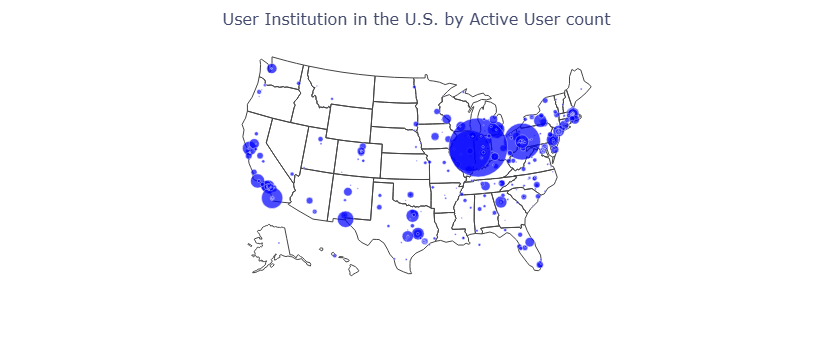

In [121]:


fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon = df['longitude'],
    lat = df['latitude'],
    text = df['User Institution Name'],
    customdata=df['active_person_count'].values,
    hovertemplate="<b>User Institution</b>: %{text}<br><b>Number of Users Active</b>: %{customdata}<br><extra></extra>",
    mode = 'markers',
    marker = dict(
        size = df['active_person_count'], 
        color = 'blue',
        line_width = 0.5,
        sizemode = 'area'
    )))

fig.update_layout(
    title_text = 'User Institution in the U.S. by Active User count',
    showlegend = True,
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(217, 217, 217)'
    )
)
fig.update_layout(showlegend=False)

fig.show()

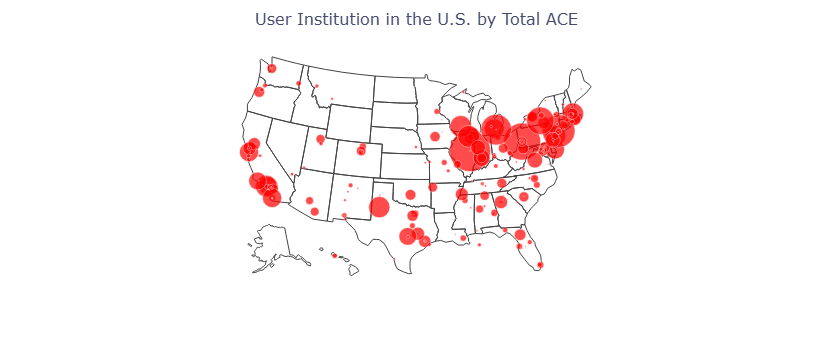

In [123]:


fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon = df['longitude'],
    lat = df['latitude'],
    text = df['User Institution Name'],
    customdata=df['total_ace'].values,
    hovertemplate="<b>User Institution</b>: %{text}<br><b>Total Ace</b>: %{customdata}<br><extra></extra>",
    mode = 'markers',
    marker = dict(
        size = df['total_ace']/100000, # had to divide by 100,000 or this would fill the whole map in red
        color = 'red',
        line_width = 0.5,
        sizemode = 'area'
    )))

fig.update_layout(
    title_text = 'User Institution in the U.S. by Total ACE',
    showlegend = True,
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(217, 217, 217)'
    )
)

fig.update_layout(showlegend=False)


fig.show()

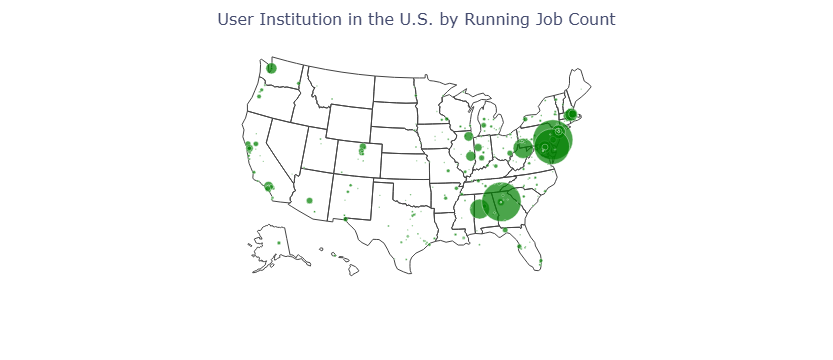

In [57]:
fig = go.Figure(data=go.Scattergeo(
    locationmode = 'USA-states',
    lon = df['longitude'],
    lat = df['latitude'],
    text = df['User Institution Name'],
    customdata=df['running_job_count'].values,
    hovertemplate="<b>User Institution</b>: %{text}<br><b>Running Job Count</b>: %{customdata}<br><extra></extra>",
    mode = 'markers',
    marker = dict(
        size = df['running_job_count'], 
        color = 'green',
        line_width = 0.5,
        sizemode = 'area'
    )))

fig.update_layout(
    title_text = 'User Institution in the U.S. by Running Job Count',
    showlegend = True,
    geo = dict(
        scope = 'usa',
        landcolor = 'rgb(217, 217, 217)'
    )
)

fig.update_layout(showlegend=False)


fig.show()

In [125]:
resources = ['Purdue Anvil CPU', 'Purdue Anvil GPU']

for resource in resources:  
    
    with dw: 
        df = dw.get_data(
            realm = 'Jobs',
            duration = (TWO_YEARS_AGO_QUARTER_START_DATE , QUARTER_END_DATE),
            metric = 'ACCESS Credit Equivalents Charged: Total (SU)', 
            dimension = 'Allocation',
            dataset_type = 'timeseries',
            aggregation_unit='Day',
            filters = {'Resource': resource},
        )
        data = dw.get_raw_data(
            duration=(TWO_YEARS_AGO_QUARTER_START_DATE, QUARTER_END_DATE),
            realm='Allocations',
            #fields=(
                #'Name',
                #'Initial Start Date',
                #'ACCESS Credit Equivalents Allocated',
            #),
            filters = {'Resource': resource},
        )
    data = data.sort_values(by='Project Charge Number')
    data = data.duplicated(subset=['Project Charge Number'], keep=False)
    data = data[data]
    display_df_md_table(data)
    
    
    data = data.sort_values(by='Name')
        
    df2 = df.ne(0).idxmax().to_frame('Date of First ACE Used')
    df2 = df2.reset_index()
    df2.rename(columns={'Allocation': 'Name'},inplace=True)
    
    data = data.groupby(['Name']).agg({'Initial Start Date': 'min'})
    
    merged_df = pd.merge(df2, data, on='Name', how='inner')
    
    merged_df[['Charge Number', 'Name']] = merged_df['Name'].str.split('-', n=1, expand=True)
    merged_df = merged_df.drop('Name', axis=1)
    columns_titles = ['Charge Number','Initial Start Date','Date of First ACE Used','ACCESS Credit Equivalents Allocated',]
    merged_df=merged_df.reindex(columns=columns_titles)
    
    
    print(resource)
    #display(merged_df)
    
#ASC160064
#ASC170016

|      |   0 |
|-----:|----:|
|  107 |   1 |
|  501 |   1 |
|  782 |   1 |
|  503 |   1 |
|  256 |   1 |
|  378 |   1 |
|  648 |   1 |
|  818 |   1 |
|   44 |   1 |
|  430 |   1 |
|    5 |   1 |
|  596 |   1 |
|  132 |   1 |
|  671 |   1 |
|  825 |   1 |
|  224 |   1 |
|  506 |   1 |
|  567 |   1 |
|    8 |   1 |
|  422 |   1 |
|  822 |   1 |
|  163 |   1 |
|  511 |   1 |
|  229 |   1 |
|  191 |   1 |
|  210 |   1 |
|  767 |   1 |
| 1030 |   1 |
|  264 |   1 |
| 1038 |   1 |
|  918 |   1 |
|  569 |   1 |
|  435 |   1 |
|   79 |   1 |
|  732 |   1 |
|  383 |   1 |
|  362 |   1 |
|  328 |   1 |
|  658 |   1 |
|  292 |   1 |
|  513 |   1 |
|  148 |   1 |
|  811 |   1 |
|  423 |   1 |
|  426 |   1 |
|  151 |   1 |
|  602 |   1 |
|   21 |   1 |
|  716 |   1 |
|  315 |   1 |
|  255 |   1 |
|  103 |   1 |
|  685 |   1 |
|  570 |   1 |
|  577 |   1 |
|  903 |   1 |
|  783 |   1 |
|  949 |   1 |
|  584 |   1 |
|  278 |   1 |
|  405 |   1 |
|   87 |   1 |
|  395 |   1 |
|   91 |   1 |
|  379 |   1 |
|  907 |   1 |
|  216 |   1 |
|  441 |   1 |
|  167 |   1 |
|  186 |   1 |
|  455 |   1 |
|  911 |   1 |
|  543 |   1 |
|  259 |   1 |
|  576 |   1 |
|  287 |   1 |
|  854 |   1 |
|  369 |   1 |
|  555 |   1 |
|  869 |   1 |
|  223 |   1 |
|  559 |   1 |
|  118 |   1 |
|  819 |   1 |
|  431 |   1 |
| 1054 |   1 |
|  293 |   1 |
|  508 |   1 |
|   48 |   1 |
|  130 |   1 |
|  429 |   1 |
|  679 |   1 |
|  219 |   1 |
|  776 |   1 |
|  476 |   1 |
|  189 |   1 |
|  159 |   1 |
|  670 |   1 |
|  350 |   1 |
|  669 |   1 |
|  660 |   1 |
|  296 |   1 |
|  448 |   1 |
|  357 |   1 |
|  850 |   1 |
|  666 |   1 |
|  298 |   1 |
|  421 |   1 |
|  372 |   1 |
|  680 |   1 |
|  545 |   1 |
|  401 |   1 |
|  502 |   1 |
|  345 |   1 |
|  837 |   1 |
|  514 |   1 |
|  152 |   1 |
|  420 |   1 |
|  515 |   1 |
|  457 |   1 |
|  813 |   1 |
|  310 |   1 |
|  640 |   1 |
|  481 |   1 |
|  192 |   1 |
|  238 |   1 |
|  826 |   1 |
|  351 |   1 |
|  676 |   1 |
|  124 |   1 |
|  526 |   1 |
|  352 |   1 |
|   45 |   1 |
|  665 |   1 |
|  663 |   1 |
|   46 |   1 |
|  139 |   1 |
|  815 |   1 |
|  347 |   1 |
|  683 |   1 |
|   42 |   1 |
| 1037 |   1 |
|  301 |   1 |
|  424 |   1 |
|  324 |   1 |
|  933 |   1 |
|  841 |   1 |
|  566 |   1 |
|  594 |   1 |
| 1044 |   1 |
|  610 |   1 |
|  119 |   1 |
|  270 |   1 |
|  557 |   1 |
|  875 |   1 |
|  402 |   1 |
|  209 |   1 |
|  185 |   1 |
|  895 |   1 |
|   78 |   1 |
|  657 |   1 |
|  539 |   1 |
|  321 |   1 |
|  162 |   1 |
|  673 |   1 |
|  295 |   1 |
|  375 |   1 |
|  620 |   1 |
|  882 |   1 |
|  923 |   1 |
|  386 |   1 |
|  771 |   1 |
|  646 |   1 |
|  608 |   1 |
| 1024 |   1 |
|  560 |   1 |
|  916 |   1 |
|  637 |   1 |
|  862 |   1 |
|  714 |   1 |
|  812 |   1 |
|  672 |   1 |
|  427 |   1 |
|  824 |   1 |
|  137 |   1 |
|  317 |   1 |
|  820 |   1 |
|  348 |   1 |
|  510 |   1 |
|  116 |   1 |
|  434 |   1 |
|  428 |   1 |
|  829 |   1 |
|  114 |   1 |
|  131 |   1 |
|  512 |   1 |
|  821 |   1 |
|  230 |   1 |
|  509 |   1 |
|  598 |   1 |
|  681 |   1 |
|  115 |   1 |
|   63 |   1 |
|  207 |   1 |
|  366 |   1 |
|  323 |   1 |
|  678 |   1 |
|  354 |   1 |
|  472 |   1 |
|   88 |   1 |
|  675 |   1 |
|  303 |   1 |
|  698 |   1 |
|  313 |   1 |
|  177 |   1 |
|  460 |   1 |
|  708 |   1 |
|  338 |   1 |
|  748 |   1 |
|  272 |   1 |
| 1018 |   1 |
|   31 |   1 |
|  334 |   1 |
|  638 |   1 |
|   70 |   1 |
|  945 |   1 |
|  377 |   1 |
|  622 |   1 |
|  122 |   1 |
|  624 |   1 |
|  265 |   1 |
|  282 |   1 |
|  612 |   1 |
|  571 |   1 |
|  762 |   1 |
|  623 |   1 |
|  934 |   1 |
|  990 |   1 |
|  652 |   1 |
|  452 |   1 |
|  211 |   1 |
|  983 |   1 |
|  887 |   1 |
|  859 |   1 |
|  432 |   1 |
|  161 |   1 |
|  307 |   1 |
|  659 |   1 |
|  418 |   1 |
|  157 |   1 |
|  851 |   1 |
|  228 |   1 |
|  706 |   1 |
|  563 |   1 |
|   47 |   1 |
|  419 |   1 |
|  129 |   1 |
|  827 |   1 |
|  299 |   1 |
|  677 |   1 |
|  667 |   1 |
|  120 |   1 |
|  144 |   1 |
|  823 |   1 |
|  707 |   1 |
|   86 |   1 |
|  374 |   1 |
|  828 |   1 |
|  425 |   1 |
|   50 |   1 |
|  609 |   1 |
|  864 |   1 |
|  552 |   1 |
|   61 |   1 |
|  208 |   1 |
|  817 |   1 |
|  516 |   1 |
|  149 |   1 |
|  400 |   1 |
|   99 |   1 |
|  197 |   1 |
|  359 |   1 |
|  731 |   1 |
|  535 |   1 |
|  641 |   1 |
|  628 |   1 |
|  553 |   1 |
|  408 |   1 |
|  412 |   1 |
| 1006 |   1 |
|  897 |   1 |
|  437 |   1 |
|  556 |   1 |
|  601 |   1 |
|  927 |   1 |
|  561 |   1 |
|  597 |   1 |
|  803 |   1 |
|  816 |   1 |
|  246 |   1 |
|  517 |   1 |
|  873 |   1 |
|  643 |   1 |
|  204 |   1 |
|  176 |   1 |
|    4 |   1 |
|  206 |   1 |
|  198 |   1 |
|  981 |   1 |
|  482 |   1 |
|  529 |   1 |
|  842 |   1 |
|  355 |   1 |
|   16 |   1 |
|  331 |   1 |
|   12 |   1 |
|  336 |   1 |
|   19 |   1 |
|   37 |   1 |
|  695 |   1 |
|  373 |   1 |
|  109 |   1 |
|  449 |   1 |
|   97 |   1 |
|  474 |   1 |
|   23 |   1 |
|  335 |   1 |
|   98 |   1 |
|  463 |   1 |
|  411 |   1 |
|  985 |   1 |
| 1067 |   1 |
|  341 |   1 |
|  656 |   1 |
|   40 |   1 |

TypeError: Series.sort_values() got an unexpected keyword argument 'by'

In [133]:
import requests
response = requests.get('https://operations-api.access-ci.org/wh2/news/v1/affiliation/access-ci.org/all_outages')
#print(f"Response JSON: {response.json()}")
data = response.json()["results"]

rows = []
for outage in data:
    subject = outage.get("Subject")
    start = outage.get("OutageStart")
    end = outage.get("OutageEnd")
    
    for resource in outage.get("AffectedResources", []):
        resource_id = resource.get("ResourceID")
        rows.append({
            "ResourceID": resource_id,
            "Subject": subject,
            "OutageStart": start,
            "OutageEnd": end
        })

df = pd.DataFrame(rows)

display(df)

,ResourceID,Subject,OutageStart,OutageEnd
0,tickets.access-ci.org,ACCESS ticketing system DB inaccessible,2022-09-04T23:00:00Z,2022-09-05T00:00:00Z
1,networking.xes.xsede.org,ORNL Emergency Fiber Maintenance,2009-08-05T04:00:00Z,2009-08-05T04:30:00Z
2,tickets.access-ci.org,ACCESS Ticketing System now live!,2022-08-29T13:00:00Z,2022-12-31T14:00:00Z
3,faster.tamu.access-ci.org,"FASTER Maintenance Thursday, Oct. 20, 2022",2022-10-20T14:00:00Z,2022-10-21T01:00:00Z
4,ranch.tacc.access-ci.org,"Ranch Storage Expansion Tuesday, 1 November 2022",2022-11-01T14:00:00Z,2022-11-02T02:00:00Z
...,...,...,...,...
1059,expanse.sdsc.access-ci.org,SDSC Expanse: Upcoming change to require two-f...,2025-02-24T17:00:00Z,2025-07-07T16:00:00Z
1060,expanse-gpu.sdsc.access-ci.org,SDSC Expanse: Upcoming change to require two-f...,2025-02-24T17:00:00Z,2025-07-07T16:00:00Z
1061,expanse-ps.sdsc.access-ci.org,SDSC Expanse: Upcoming change to require two-f...,2025-02-24T17:00:00Z,2025-07-07T16:00:00Z
1062,kerberos.access-ci.org,Kerberos Replica DNS Work,2025-03-18T18:00:00Z,2025-03-18T19:00:00Z
